# AgriMind Final Integration Notebook

## Purpose

This notebook is the final integration notebook for the AgriMind project.

It does **not** train new models.  
It summarizes and verifies all completed phases:

1. Phase 1: CNN plant disease detection  
2. Phase 2: Federated CNN plant disease detection  
3. Phase 3: RNN / LSTM / GRU crop price forecasting  
4. Phase 4: ANN fertilizer recommendation  
5. Phase 5: Reinforcement Learning fertilizer scheduling agent  
6. Phase 6: Expert System chemical safety checker  

## Final notebook goal

This notebook helps prepare:

- final project summary
- final result tables
- demo flow
- report content
- presentation screenshots
- saved final outputs

After this notebook is completed, the coding/model-development part of the project can be considered complete.

In [1]:
# ============================================================
# Block 1: Import libraries
# ============================================================

import os
import json
import glob
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Image

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Block 2: Define project paths
# ============================================================

PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

DATASETS_DIR = os.path.join(PROJECT_DIR, "datasets")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
SCREENSHOTS_DIR = os.path.join(PROJECT_DIR, "screenshots")
NOTEBOOKS_DIR = os.path.join(PROJECT_DIR, "notebooks")

FINAL_RESULTS_DIR = os.path.join(RESULTS_DIR, "phase7_final_integration")
FINAL_SCREENSHOTS_DIR = os.path.join(SCREENSHOTS_DIR, "phase7_final_integration")

os.makedirs(FINAL_RESULTS_DIR, exist_ok=True)
os.makedirs(FINAL_SCREENSHOTS_DIR, exist_ok=True)

paths = {
    "PROJECT_DIR": PROJECT_DIR,
    "DATASETS_DIR": DATASETS_DIR,
    "MODELS_DIR": MODELS_DIR,
    "RESULTS_DIR": RESULTS_DIR,
    "SCREENSHOTS_DIR": SCREENSHOTS_DIR,
    "NOTEBOOKS_DIR": NOTEBOOKS_DIR,
    "FINAL_RESULTS_DIR": FINAL_RESULTS_DIR,
    "FINAL_SCREENSHOTS_DIR": FINAL_SCREENSHOTS_DIR
}

for name, path in paths.items():
    print(name, ":", path, "| Exists:", os.path.exists(path))

PROJECT_DIR : E:\AI Project\AgriMind_Project | Exists: True
DATASETS_DIR : E:\AI Project\AgriMind_Project\datasets | Exists: True
MODELS_DIR : E:\AI Project\AgriMind_Project\models | Exists: True
RESULTS_DIR : E:\AI Project\AgriMind_Project\results | Exists: True
SCREENSHOTS_DIR : E:\AI Project\AgriMind_Project\screenshots | Exists: True
NOTEBOOKS_DIR : E:\AI Project\AgriMind_Project\notebooks | Exists: True
FINAL_RESULTS_DIR : E:\AI Project\AgriMind_Project\results\phase7_final_integration | Exists: True
FINAL_SCREENSHOTS_DIR : E:\AI Project\AgriMind_Project\screenshots\phase7_final_integration | Exists: True


In [3]:
# ============================================================
# Block 3: Define phase folders
# ============================================================

phase_paths = {
    "phase1_cnn": {
        "model_dir": os.path.join(MODELS_DIR, "phase1_cnn"),
        "results_dir": os.path.join(RESULTS_DIR, "phase1_cnn"),
        "screenshots_dir": os.path.join(SCREENSHOTS_DIR, "phase1_cnn")
    },
    "phase2_federated_cnn": {
        "model_dir": os.path.join(MODELS_DIR, "phase2_federated_cnn"),
        "results_dir": os.path.join(RESULTS_DIR, "phase2_federated_cnn"),
        "screenshots_dir": os.path.join(SCREENSHOTS_DIR, "phase2_federated_cnn")
    },
    "phase3_crop_price_forecasting": {
        "model_dir": os.path.join(MODELS_DIR, "phase3_crop_price_forecasting"),
        "results_dir": os.path.join(RESULTS_DIR, "phase3_crop_price_forecasting"),
        "screenshots_dir": os.path.join(SCREENSHOTS_DIR, "phase3_crop_price_forecasting")
    },
    "phase4_ann_fertilizer": {
        "model_dir": os.path.join(MODELS_DIR, "phase4_ann_improved_fertilizer_recommendation"),
        "results_dir": os.path.join(RESULTS_DIR, "phase4_ann_improved_fertilizer_recommendation"),
        "screenshots_dir": os.path.join(SCREENSHOTS_DIR, "phase4_ann_improved_fertilizer_recommendation")
    },
    "phase5_rl_scheduling": {
        "model_dir": os.path.join(MODELS_DIR, "phase5_rl_guideline_ready_fertilizer_scheduling"),
        "results_dir": os.path.join(RESULTS_DIR, "phase5_rl_guideline_ready_fertilizer_scheduling"),
        "screenshots_dir": os.path.join(SCREENSHOTS_DIR, "phase5_rl_guideline_ready_fertilizer_scheduling")
    },
    "phase6_expert_system": {
        "model_dir": os.path.join(MODELS_DIR, "phase6_expert_system_chemical_safety"),
        "results_dir": os.path.join(RESULTS_DIR, "phase6_expert_system_chemical_safety"),
        "screenshots_dir": os.path.join(SCREENSHOTS_DIR, "phase6_expert_system_chemical_safety")
    }
}

folder_check_rows = []

for phase, folders in phase_paths.items():
    for folder_type, folder_path in folders.items():
        folder_check_rows.append({
            "Phase": phase,
            "Folder_Type": folder_type,
            "Path": folder_path,
            "Exists": os.path.exists(folder_path)
        })

folder_check_df = pd.DataFrame(folder_check_rows)
display(folder_check_df)

folder_check_path = os.path.join(FINAL_RESULTS_DIR, "final_folder_check.csv")
folder_check_df.to_csv(folder_check_path, index=False)

print("Folder check saved at:", folder_check_path)

,Phase,Folder_Type,Path,Exists
0,phase1_cnn,model_dir,E:\AI Project\AgriMind_Project\models\phase1_cnn,True
1,phase1_cnn,results_dir,E:\AI Project\AgriMind_Project\results\phase1_cnn,True
2,phase1_cnn,screenshots_dir,E:\AI Project\AgriMind_Project\screenshots\pha...,True
3,phase2_federated_cnn,model_dir,E:\AI Project\AgriMind_Project\models\phase2_f...,True
4,phase2_federated_cnn,results_dir,E:\AI Project\AgriMind_Project\results\phase2_...,True
5,phase2_federated_cnn,screenshots_dir,E:\AI Project\AgriMind_Project\screenshots\pha...,True
6,phase3_crop_price_forecasting,model_dir,E:\AI Project\AgriMind_Project\models\phase3_c...,True
7,phase3_crop_price_forecasting,results_dir,E:\AI Project\AgriMind_Project\results\phase3_...,True
8,phase3_crop_price_forecasting,screenshots_dir,E:\AI Project\AgriMind_Project\screenshots\pha...,True
9,phase4_ann_fertilizer,model_dir,E:\AI Project\AgriMind_Project\models\phase4_a...,True


Folder check saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_folder_check.csv


In [4]:
# ============================================================
# Block 4: Helper functions to load result files safely
# ============================================================

def find_files(folder, pattern):
    if not os.path.exists(folder):
        return []
    return glob.glob(os.path.join(folder, pattern))

def load_first_csv(folder, pattern):
    files = find_files(folder, pattern)
    if len(files) == 0:
        return None, None
    file_path = files[0]
    try:
        return pd.read_csv(file_path), file_path
    except Exception as e:
        print("Could not read:", file_path)
        print("Error:", e)
        return None, file_path

def load_json_if_exists(path):
    if os.path.exists(path):
        with open(path, "r") as f:
            return json.load(f)
    return None

def show_image_if_exists(path, title=None):
    if os.path.exists(path):
        if title:
            print(title)
        display(Image(filename=path))
    else:
        print("Image not found:", path)

def list_files_in_folder(folder_path, file_types=None):
    if not os.path.exists(folder_path):
        return []

    files = []

    for root, dirs, filenames in os.walk(folder_path):
        for filename in filenames:
            if file_types is None:
                files.append(os.path.join(root, filename))
            else:
                if filename.lower().endswith(tuple(file_types)):
                    files.append(os.path.join(root, filename))

    return files

print("Helper functions created.")

Helper functions created.


In [5]:
# ============================================================
# Block 5: Final objective mapping according to proposal
# ============================================================

objective_mapping = pd.DataFrame([
    {
        "Objective": "Objective 1",
        "Proposal Requirement": "CNN plant disease detection using Federated Learning for privacy",
        "Completed Phase": "Phase 1 + Phase 2",
        "AI Type": "CNN + Federated Learning",
        "Main Output": "Disease detection model and federated CNN model",
        "Status": "Completed"
    },
    {
        "Objective": "Objective 2",
        "Proposal Requirement": "Compare RNN, LSTM, and GRU for future price prediction",
        "Completed Phase": "Phase 3",
        "AI Type": "RNN / LSTM / GRU",
        "Main Output": "Best forecasting model selected using MAE, RMSE, MAPE, and R²",
        "Status": "Completed"
    },
    {
        "Objective": "Objective 3",
        "Proposal Requirement": "RL agent for optimal fertilizer schedule with minimum cost",
        "Completed Phase": "Phase 5",
        "AI Type": "Reinforcement Learning / Q-learning",
        "Main Output": "RL policy for fertilizer scheduling",
        "Status": "Completed"
    },
    {
        "Objective": "Objective 4",
        "Proposal Requirement": "Expert System to prevent unsafe chemical combinations",
        "Completed Phase": "Phase 6",
        "AI Type": "Symbolic AI / Rule-Based AI",
        "Main Output": "Chemical safety checker",
        "Status": "Completed"
    },
    {
        "Objective": "Objective 5",
        "Proposal Requirement": "ANN to analyze soil test numbers and recommend nutrients",
        "Completed Phase": "Phase 4",
        "AI Type": "Artificial Neural Network",
        "Main Output": "Fertilizer recommendation model",
        "Status": "Completed"
    }
])

display(objective_mapping)

objective_mapping_path = os.path.join(FINAL_RESULTS_DIR, "final_objective_mapping.csv")
objective_mapping.to_csv(objective_mapping_path, index=False)

print("Objective mapping saved at:", objective_mapping_path)

,Objective,Proposal Requirement,Completed Phase,AI Type,Main Output,Status
0,Objective 1,CNN plant disease detection using Federated Le...,Phase 1 + Phase 2,CNN + Federated Learning,Disease detection model and federated CNN model,Completed
1,Objective 2,"Compare RNN, LSTM, and GRU for future price pr...",Phase 3,RNN / LSTM / GRU,"Best forecasting model selected using MAE, RMS...",Completed
2,Objective 3,RL agent for optimal fertilizer schedule with ...,Phase 5,Reinforcement Learning / Q-learning,RL policy for fertilizer scheduling,Completed
3,Objective 4,Expert System to prevent unsafe chemical combi...,Phase 6,Symbolic AI / Rule-Based AI,Chemical safety checker,Completed
4,Objective 5,ANN to analyze soil test numbers and recommend...,Phase 4,Artificial Neural Network,Fertilizer recommendation model,Completed


Objective mapping saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_objective_mapping.csv


In [6]:
# ============================================================
# Block 6: Manually recorded final results from completed phases
# ============================================================

# These values are taken from your completed phase outputs.

final_results = pd.DataFrame([
    {
        "Phase": "Phase 1",
        "Component": "CNN Plant Disease Detection",
        "AI_Type": "CNN / Deep Learning",
        "Main_Result": "Trained centralized CNN disease detection model",
        "Key_Metric": "Refer Phase 1 results folder",
        "Status": "Completed"
    },
    {
        "Phase": "Phase 2",
        "Component": "Federated CNN Disease Detection",
        "AI_Type": "Federated Learning + CNN",
        "Main_Result": "Trained federated CNN disease detection model",
        "Key_Metric": "Refer Phase 2 results folder",
        "Status": "Completed"
    },
    {
        "Phase": "Phase 3",
        "Component": "Crop Price Forecasting",
        "AI_Type": "RNN / LSTM / GRU",
        "Main_Result": "Best model: GRU; Selected commodity: Coconut",
        "Key_Metric": "GRU RMSE = 656.35, R² = 0.4382",
        "Status": "Completed"
    },
    {
        "Phase": "Phase 4",
        "Component": "ANN Fertilizer Recommendation",
        "AI_Type": "Artificial Neural Network",
        "Main_Result": "Improved ANN fertilizer recommendation model",
        "Key_Metric": "Accuracy = 98.45%, F1-score = 98.53%",
        "Status": "Completed"
    },
    {
        "Phase": "Phase 5",
        "Component": "RL Fertilizer Scheduling Agent",
        "AI_Type": "Q-learning / Reinforcement Learning",
        "Main_Result": "RL policy learned fertilizer scheduling actions",
        "Key_Metric": "Reward improvement = 185.1642; Test improvement over random = 267.8365",
        "Status": "Completed"
    },
    {
        "Phase": "Phase 6",
        "Component": "Expert System Chemical Safety Checker",
        "AI_Type": "Symbolic AI / Rule-Based AI",
        "Main_Result": "Rule-based safety checker with 12 rules",
        "Key_Metric": "Accuracy = 100%; False-safe cases = 0; Rule coverage = 91.67%",
        "Status": "Completed"
    }
])

display(final_results)

final_results_path = os.path.join(FINAL_RESULTS_DIR, "final_phase_results_summary.csv")
final_results.to_csv(final_results_path, index=False)

print("Final phase results summary saved at:", final_results_path)

,Phase,Component,AI_Type,Main_Result,Key_Metric,Status
0,Phase 1,CNN Plant Disease Detection,CNN / Deep Learning,Trained centralized CNN disease detection model,Refer Phase 1 results folder,Completed
1,Phase 2,Federated CNN Disease Detection,Federated Learning + CNN,Trained federated CNN disease detection model,Refer Phase 2 results folder,Completed
2,Phase 3,Crop Price Forecasting,RNN / LSTM / GRU,Best model: GRU; Selected commodity: Coconut,"GRU RMSE = 656.35, R² = 0.4382",Completed
3,Phase 4,ANN Fertilizer Recommendation,Artificial Neural Network,Improved ANN fertilizer recommendation model,"Accuracy = 98.45%, F1-score = 98.53%",Completed
4,Phase 5,RL Fertilizer Scheduling Agent,Q-learning / Reinforcement Learning,RL policy learned fertilizer scheduling actions,Reward improvement = 185.1642; Test improvemen...,Completed
5,Phase 6,Expert System Chemical Safety Checker,Symbolic AI / Rule-Based AI,Rule-based safety checker with 12 rules,Accuracy = 100%; False-safe cases = 0; Rule co...,Completed


Final phase results summary saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_phase_results_summary.csv


In [7]:
# ============================================================
# Block 7: Load Phase 3 result table if available
# ============================================================

phase3_results_df, phase3_results_file = load_first_csv(
    phase_paths["phase3_crop_price_forecasting"]["results_dir"],
    "*results*.csv"
)

print("Phase 3 result file:", phase3_results_file)

if phase3_results_df is not None:
    display(phase3_results_df)
else:
    print("Phase 3 results CSV not found. Manual result already included in final summary.")

Phase 3 result file: E:\AI Project\AgriMind_Project\results\phase3_crop_price_forecasting\phase3_rnn_lstm_gru_crop_price_results.csv


,Model,MAE,MSE,RMSE,MAPE,R2_Score
0,RNN,536.248168,536861.243686,732.708157,13.213715,0.299877
1,LSTM,482.138024,439052.838040,662.610623,12.953982,0.427429
2,GRU,496.858245,430792.417759,656.347787,13.401984,0.438202


In [8]:
# ============================================================
# Block 8: Load Phase 4 result table if available
# ============================================================

phase4_results_df, phase4_results_file = load_first_csv(
    phase_paths["phase4_ann_fertilizer"]["results_dir"],
    "*results*.csv"
)

print("Phase 4 result file:", phase4_results_file)

if phase4_results_df is not None:
    display(phase4_results_df)
else:
    print("Phase 4 results CSV not found. Manual result already included in final summary.")

Phase 4 result file: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation\phase4_improved_ann_fertilizer_results.csv


,Phase,Module,Dataset,Best_Config,Model,Accuracy,Precision,Recall,F1_score,Top_3_Accuracy,Test_Loss,Target_Column,Number_of_Classes,Number_of_Original_Features,Number_of_Encoded_Features,Fit_Diagnosis
0,Phase 4,Improved ANN Fertilizer Recommendation,Crop and Fertilizer Dataset for Western Mahara...,strong_3,Artificial Neural Network,0.984513,0.987924,0.984513,0.985279,0.997788,0.165421,fertilizer,19,15,71,No strong overfitting/underfitting sign based ...


In [9]:
# ============================================================
# Block 9: Load Phase 5 result table if available
# ============================================================

phase5_results_df, phase5_results_file = load_first_csv(
    phase_paths["phase5_rl_scheduling"]["results_dir"],
    "*results*.csv"
)

print("Phase 5 result file:", phase5_results_file)

if phase5_results_df is not None:
    display(phase5_results_df)
else:
    print("Phase 5 results CSV not found. Manual result already included in final summary.")

Phase 5 result file: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_fertilizer_scheduling_results.csv


,Phase,Module,Algorithm,Number_of_States,Number_of_Actions,Episodes,Max_Steps_Per_Episode,Initial_Average_Reward_First_100,Final_Average_Reward_Last_100,Reward_Improvement,Train_Average_Reward,Test_Average_Reward,Random_Test_Average_Reward,Test_Improvement_Over_Random,Final_Epsilon,Fit_Diagnosis
0,Phase 5,Guideline-Ready RL Fertilizer Scheduling Agent,Q-learning,81,5,6000,20,-54.8066,130.3576,185.1642,145.56496,145.5044,-122.33208,267.83648,0.05,No strong overfitting/underfitting sign: learn...


In [10]:
# ============================================================
# Block 10: Load Phase 6 result table if available
# ============================================================

phase6_metrics_df, phase6_metrics_file = load_first_csv(
    phase_paths["phase6_expert_system"]["results_dir"],
    "*metrics*.csv"
)

print("Phase 6 metrics file:", phase6_metrics_file)

if phase6_metrics_df is not None:
    display(phase6_metrics_df)
else:
    print("Phase 6 metrics CSV not found. Manual result already included in final summary.")

Phase 6 metrics file: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety\phase6_evaluation_metrics.csv


,Accuracy,Precision,Recall,F1_score,Total_Test_Cases,Correct_Predictions,Wrong_Predictions
0,1.0,1.0,1.0,1.0,18,18,0


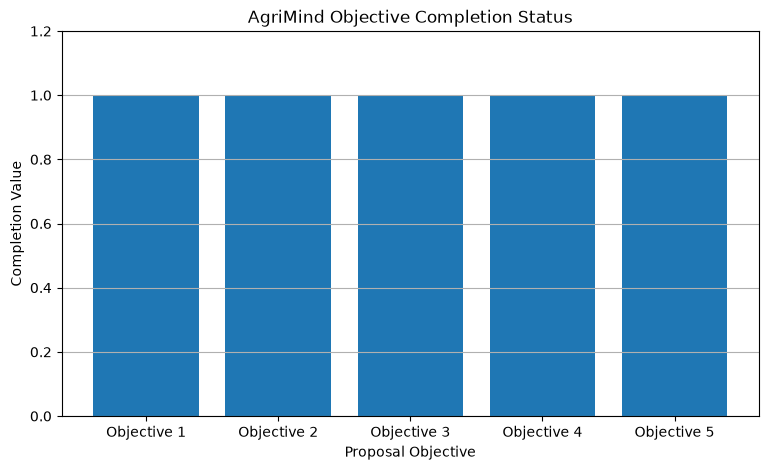

Objective completion graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase7_final_integration\final_objective_completion_status.png


In [11]:
# ============================================================
# Block 11: Visualize objective completion
# ============================================================

completion_df = objective_mapping.copy()
completion_df["Completed_Value"] = completion_df["Status"].apply(lambda x: 1 if x == "Completed" else 0)

plt.figure(figsize=(9, 5))
plt.bar(completion_df["Objective"], completion_df["Completed_Value"])
plt.title("AgriMind Objective Completion Status")
plt.xlabel("Proposal Objective")
plt.ylabel("Completion Value")
plt.ylim(0, 1.2)
plt.grid(axis="y")

objective_completion_path = os.path.join(
    FINAL_SCREENSHOTS_DIR,
    "final_objective_completion_status.png"
)

plt.savefig(objective_completion_path, dpi=300, bbox_inches="tight")
plt.show()

print("Objective completion graph saved at:", objective_completion_path)

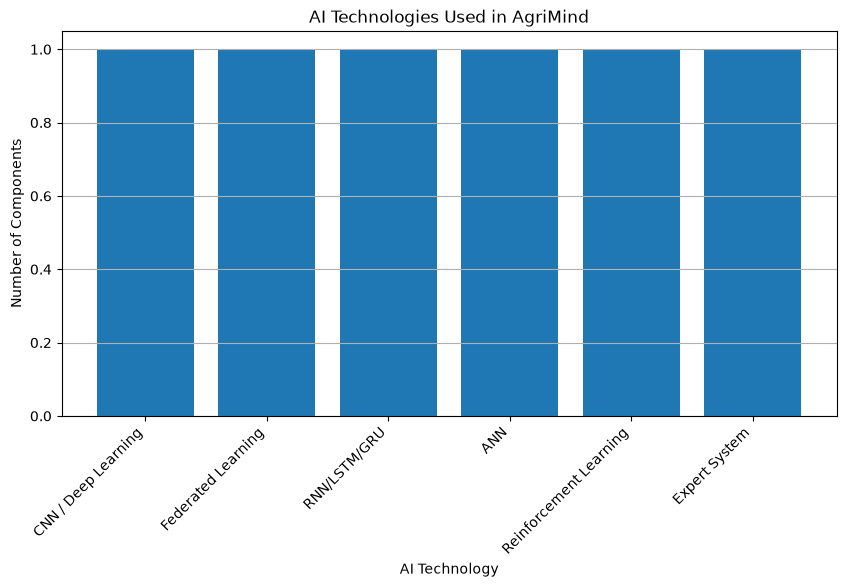

AI technology distribution graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase7_final_integration\final_ai_technology_distribution.png


In [12]:
# ============================================================
# Block 12: Visualize AI technology distribution
# ============================================================

ai_technology_df = pd.DataFrame([
    {"AI_Technology": "CNN / Deep Learning", "Count": 1},
    {"AI_Technology": "Federated Learning", "Count": 1},
    {"AI_Technology": "RNN/LSTM/GRU", "Count": 1},
    {"AI_Technology": "ANN", "Count": 1},
    {"AI_Technology": "Reinforcement Learning", "Count": 1},
    {"AI_Technology": "Expert System", "Count": 1}
])

plt.figure(figsize=(10, 5))
plt.bar(ai_technology_df["AI_Technology"], ai_technology_df["Count"])
plt.title("AI Technologies Used in AgriMind")
plt.xlabel("AI Technology")
plt.ylabel("Number of Components")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

ai_technology_path = os.path.join(
    FINAL_SCREENSHOTS_DIR,
    "final_ai_technology_distribution.png"
)

plt.savefig(ai_technology_path, dpi=300, bbox_inches="tight")
plt.show()

print("AI technology distribution graph saved at:", ai_technology_path)

Phase 1: CNN Plant Disease Detection
Phase 1 model files:
- E:\AI Project\AgriMind_Project\models\phase1_cnn\agrimind_tomato_cnn_model.h5
- E:\AI Project\AgriMind_Project\models\phase1_cnn\agrimind_tomato_cnn_model.keras
- E:\AI Project\AgriMind_Project\models\phase1_cnn\class_names.json

Phase 1 result files:
- E:\AI Project\AgriMind_Project\results\phase1_cnn\phase1_cnn_results.csv

Phase 1 screenshots:
- No screenshots found in expected Phase 1 screenshots folder.
Phase 2: Federated CNN Plant Disease Detection
Phase 2 model files:
- E:\AI Project\AgriMind_Project\models\phase2_federated_cnn\agrimind_federated_cnn_model.h5
- E:\AI Project\AgriMind_Project\models\phase2_federated_cnn\agrimind_federated_cnn_model.keras
- E:\AI Project\AgriMind_Project\models\phase2_federated_cnn\class_names.json

Phase 2 result files:
- E:\AI Project\AgriMind_Project\results\phase2_federated_cnn\centralized_vs_federated_comparison.csv
- E:\AI Project\AgriMind_Project\results\phase2_federated_cnn\phase2

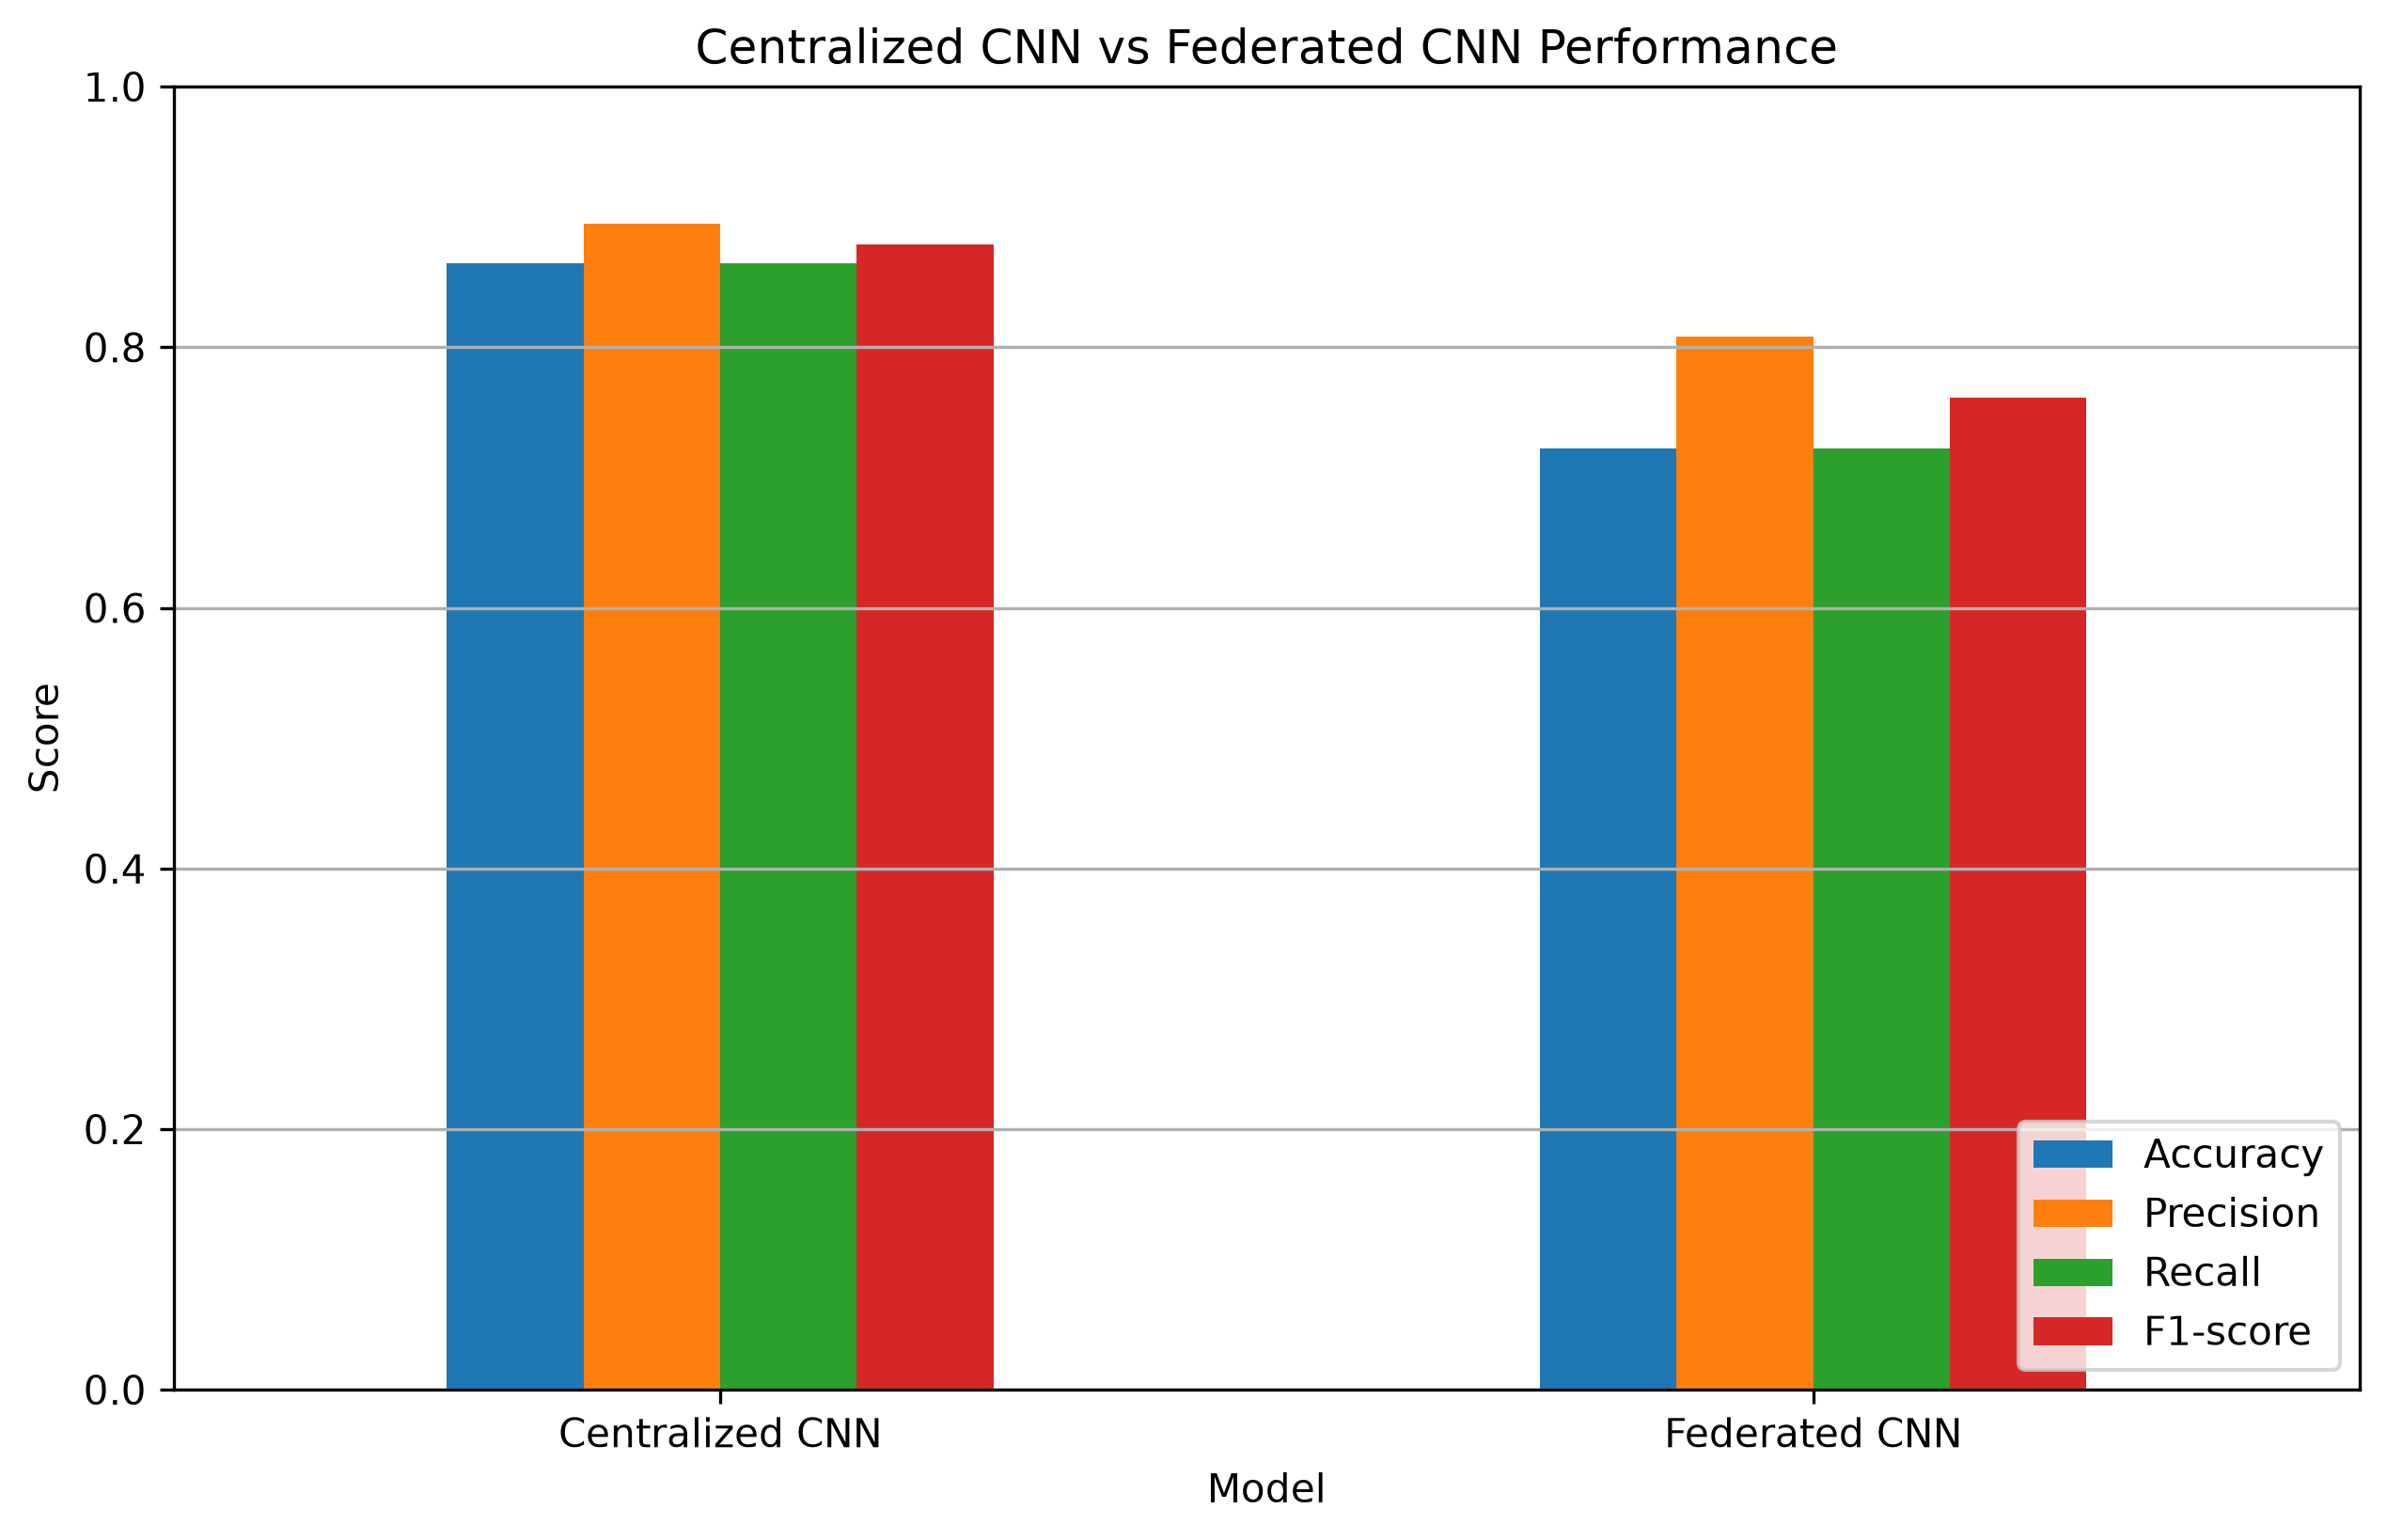


Displaying: phase2_federated_accuracy_graph.png


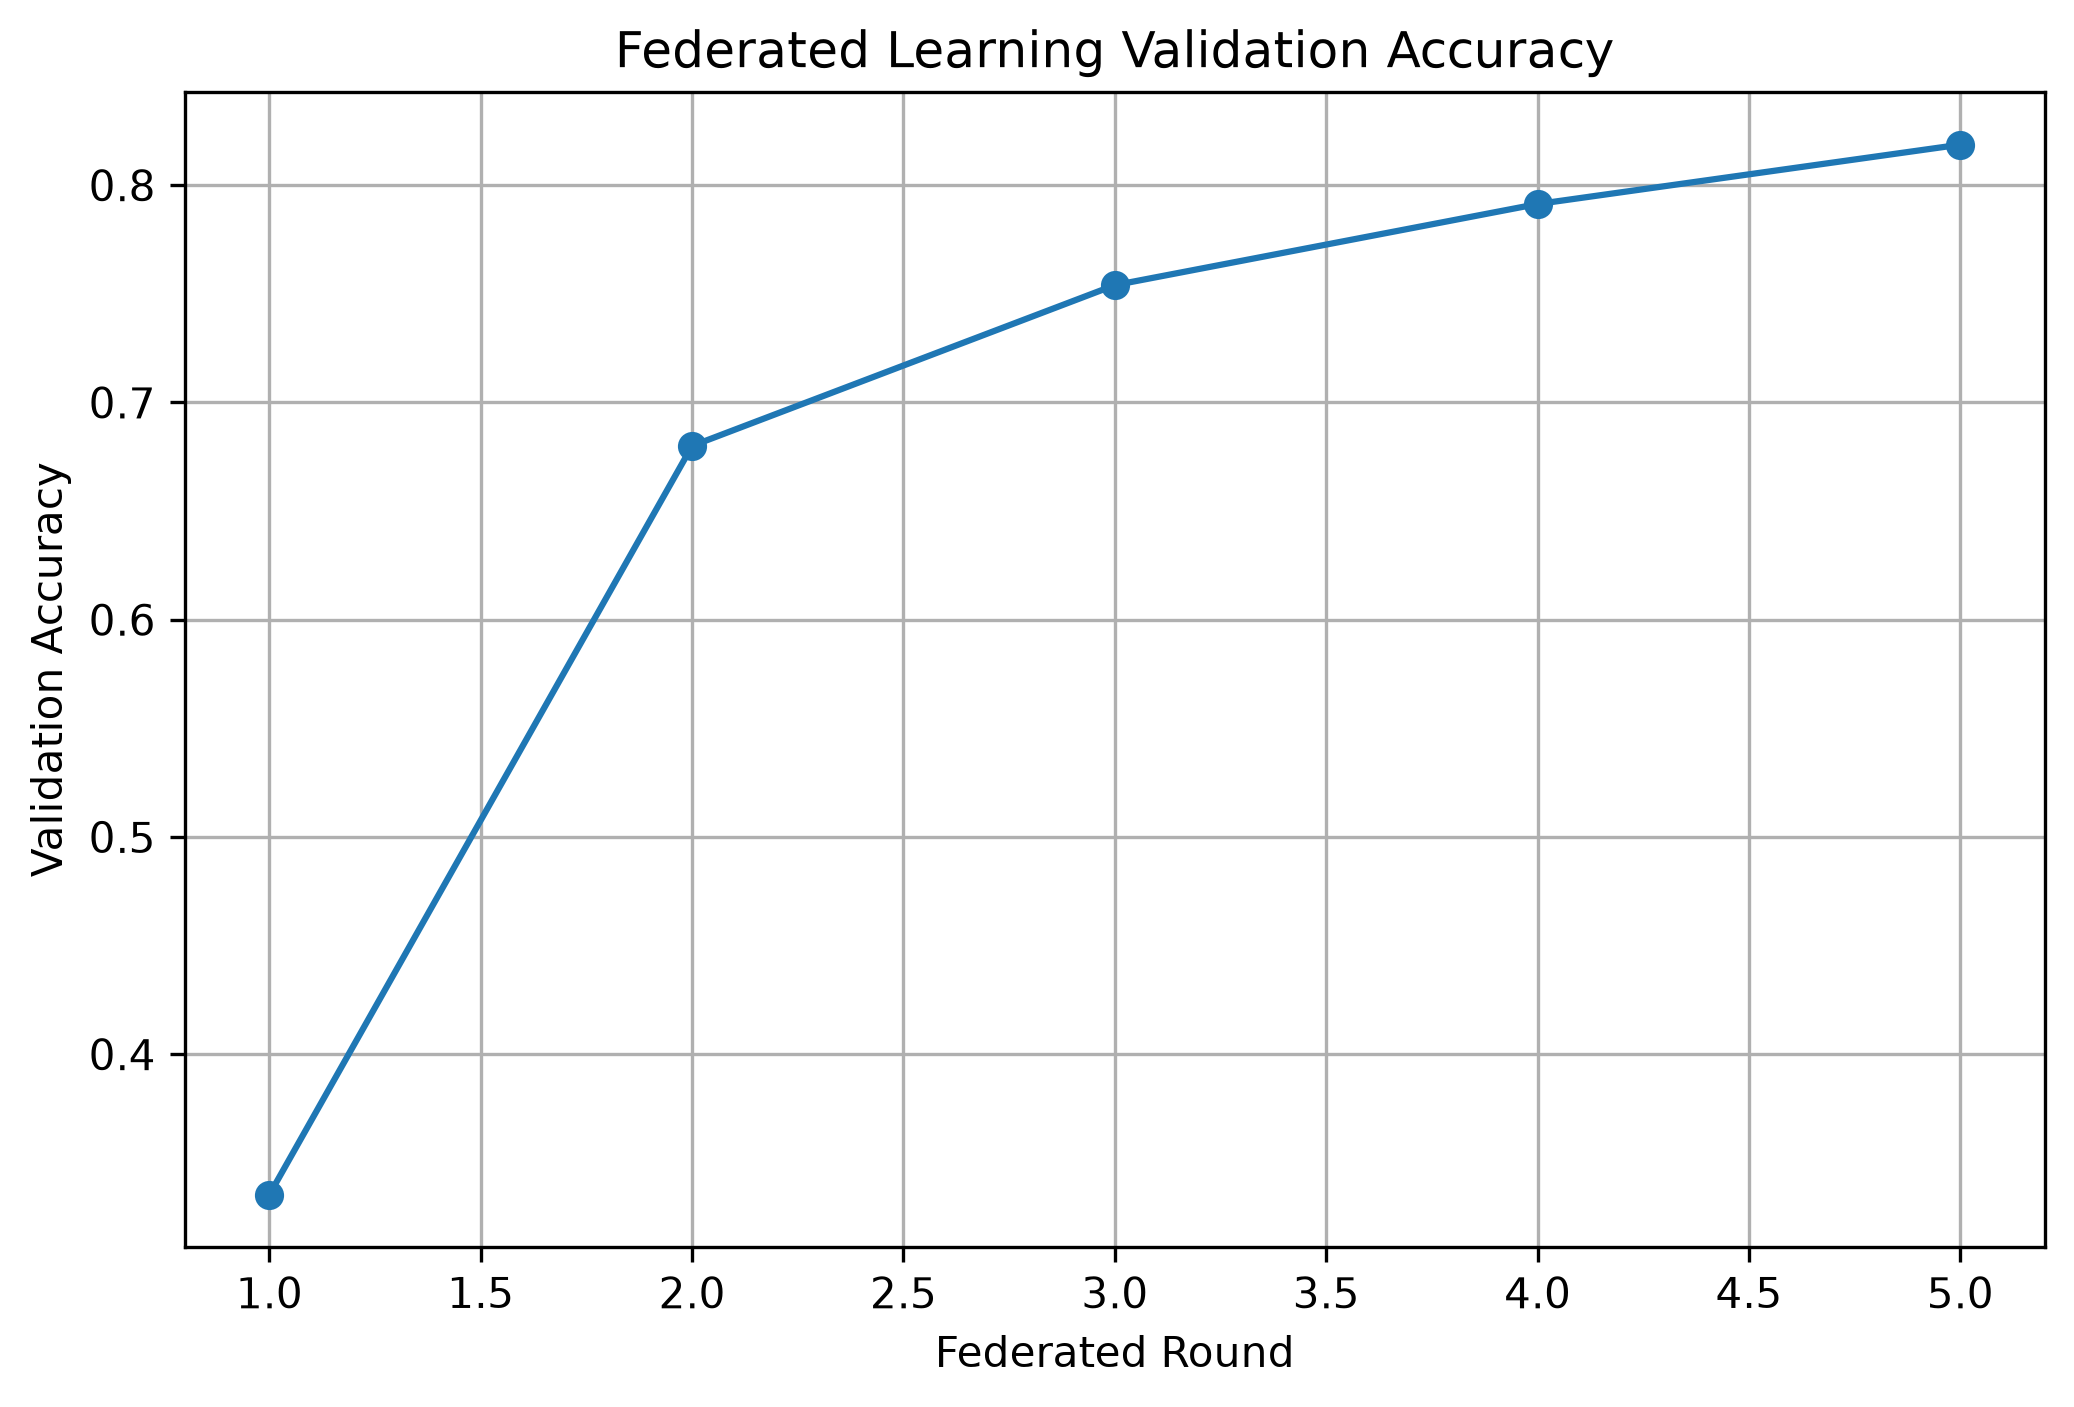


Displaying: phase2_federated_confusion_matrix.png


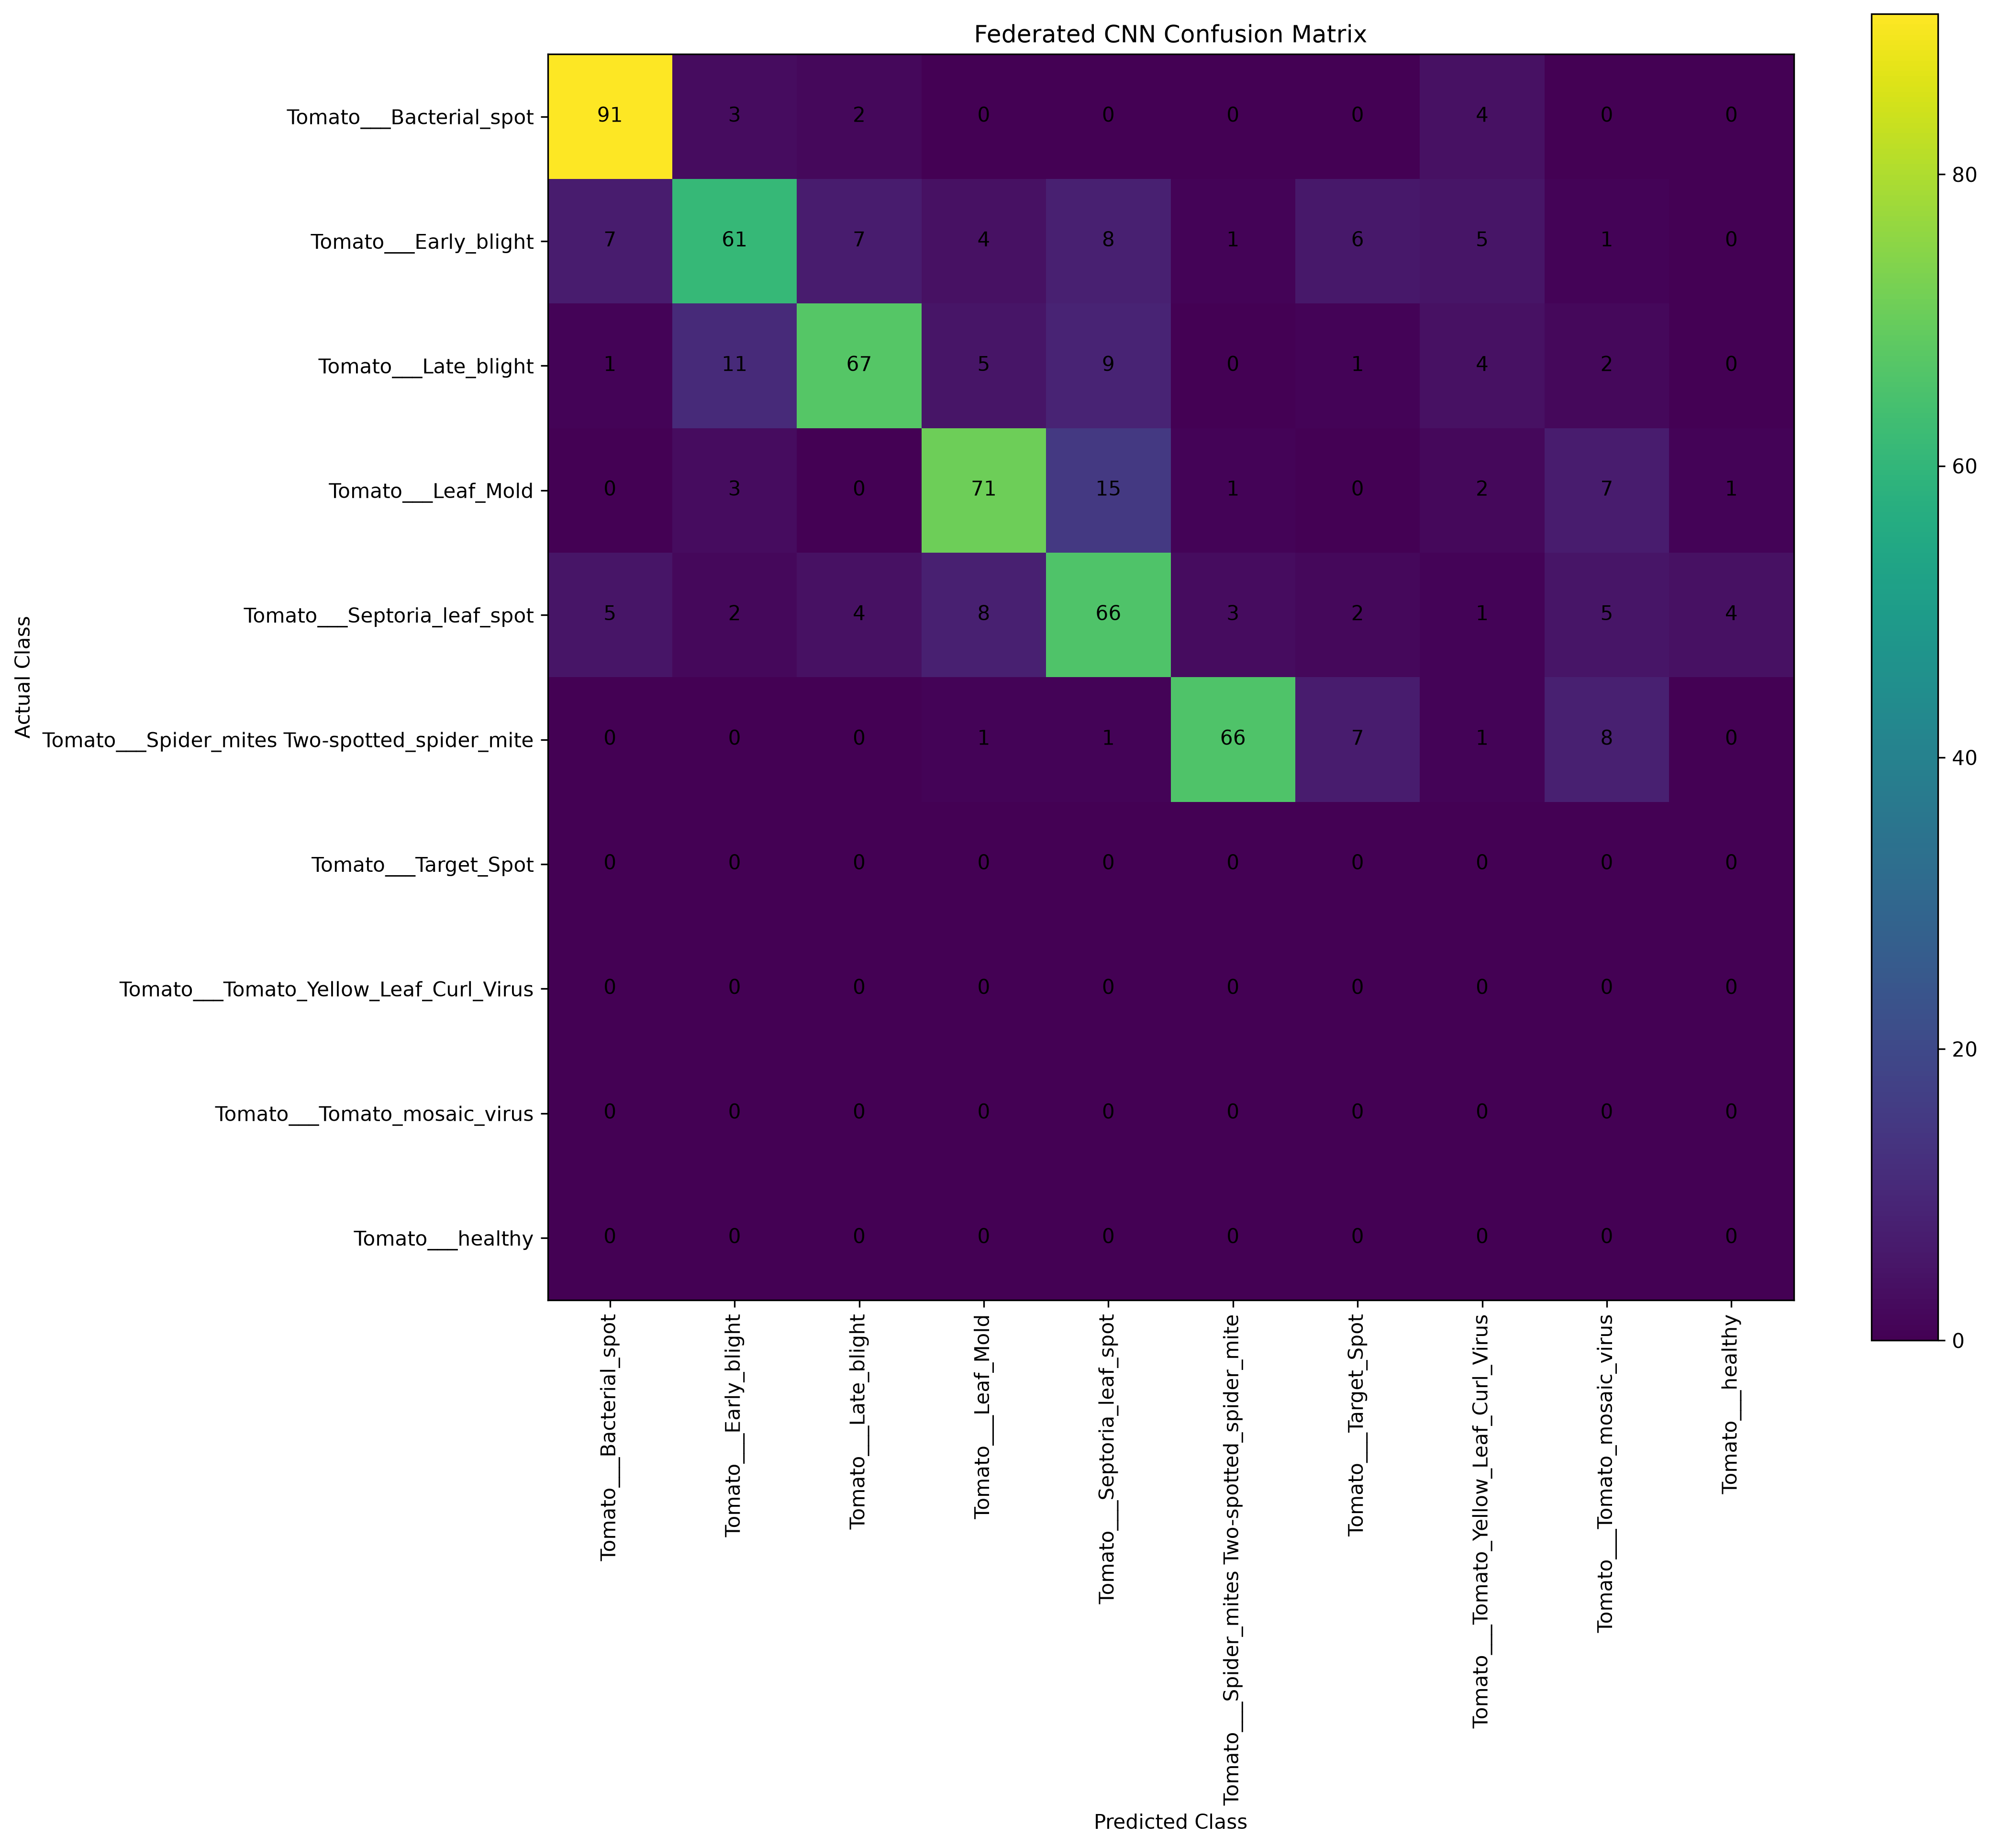


Displaying: phase2_federated_loss_graph.png


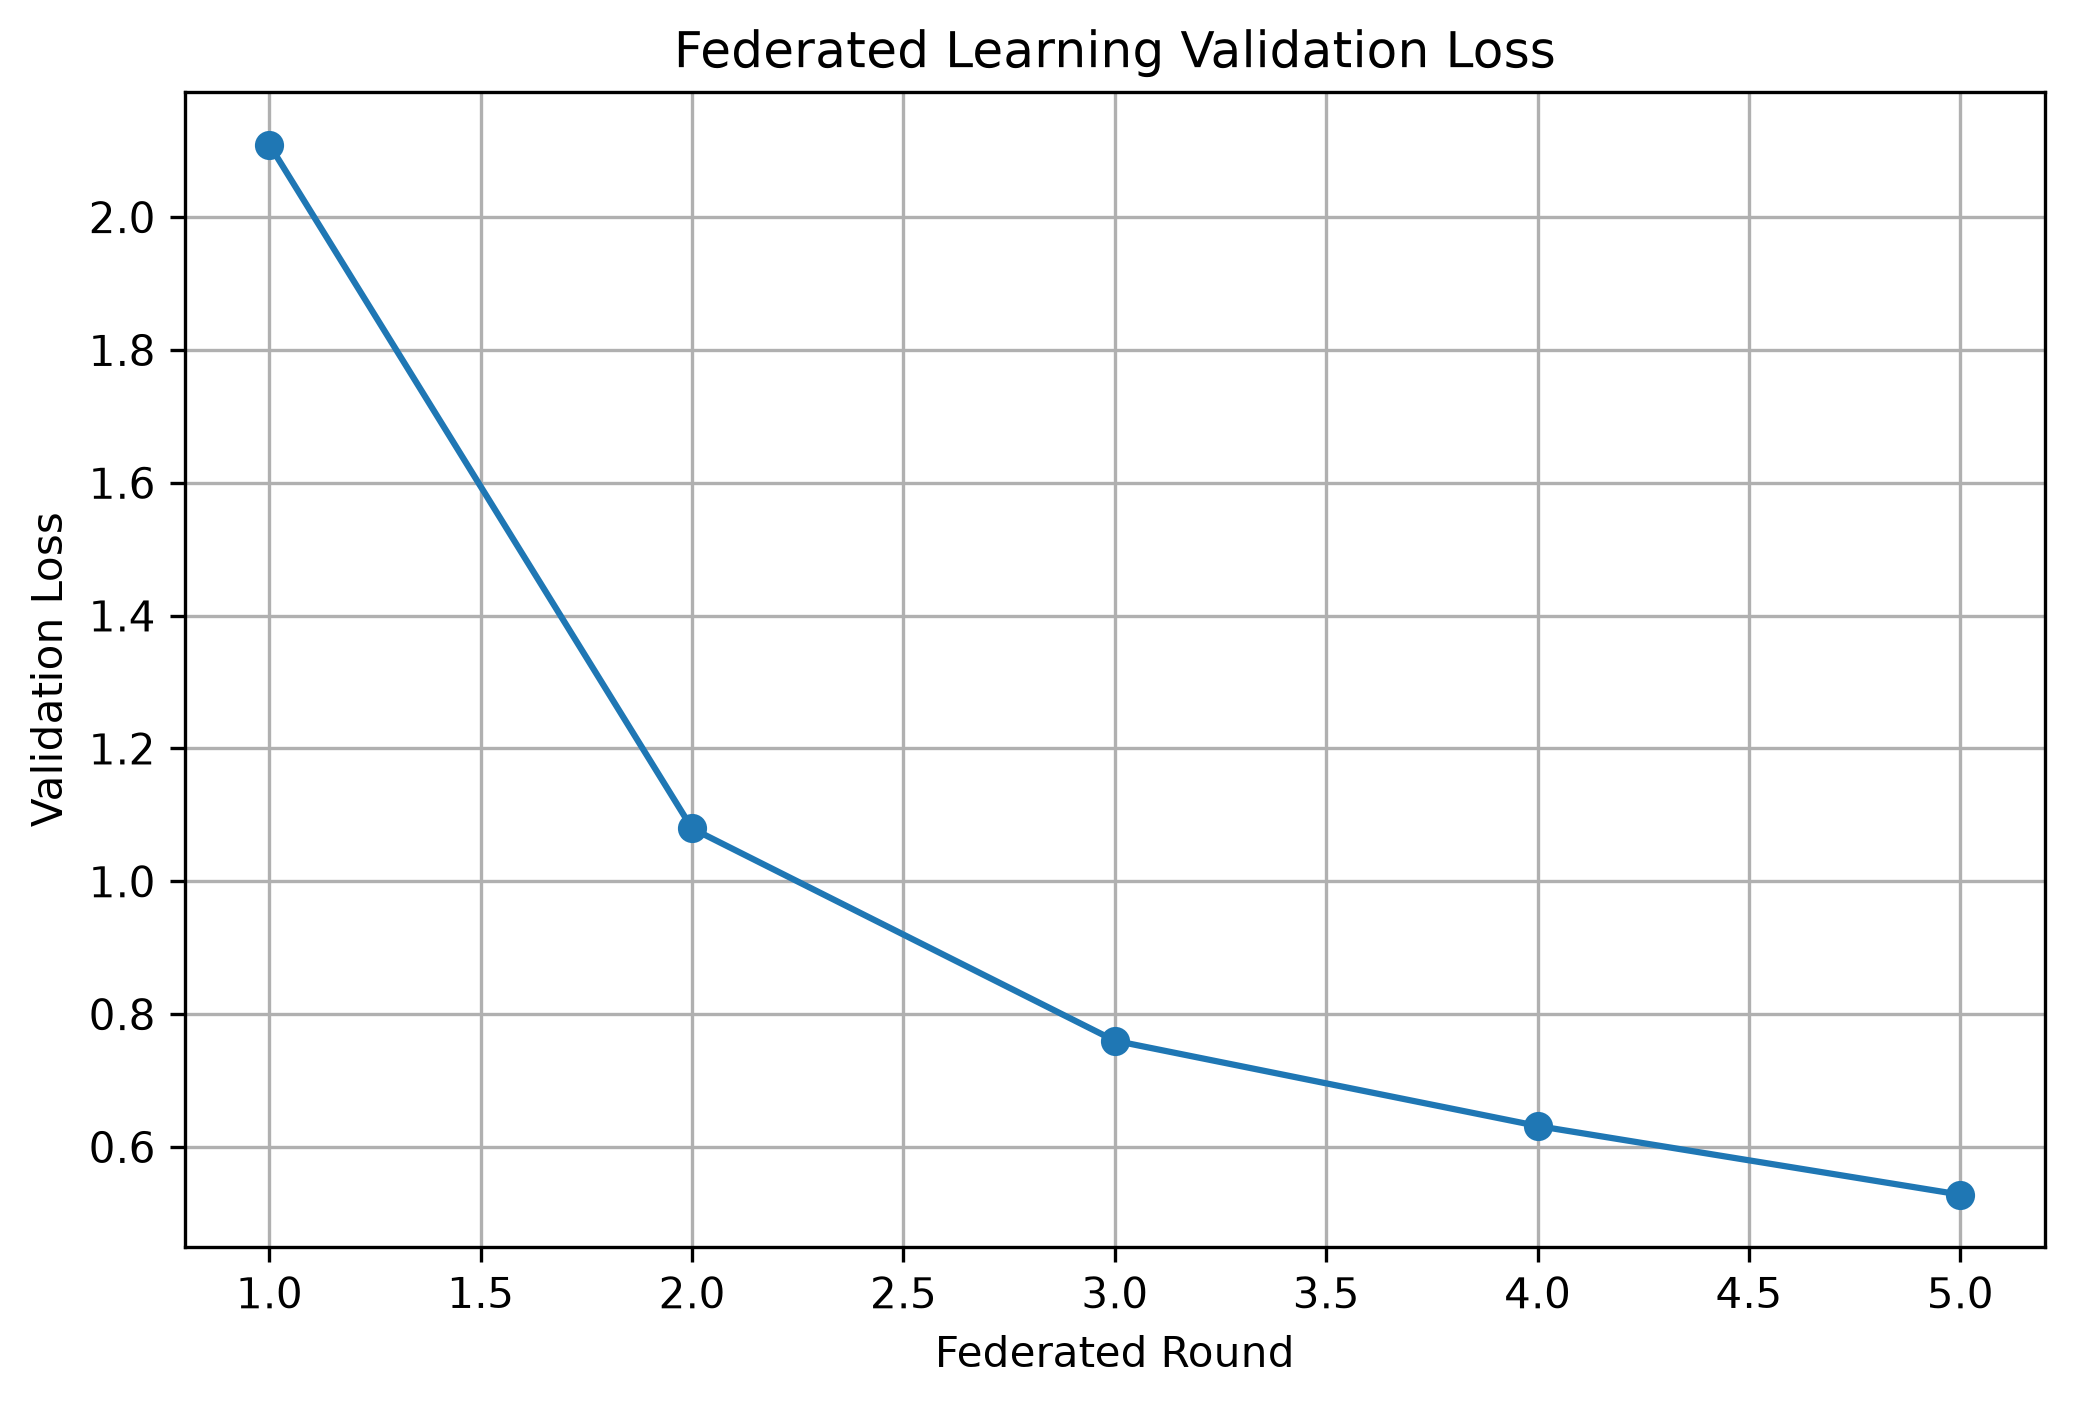

,Phase,File_Type,Path
0,Phase 1,Model,E:\AI Project\AgriMind_Project\models\phase1_c...
1,Phase 1,Model,E:\AI Project\AgriMind_Project\models\phase1_c...
2,Phase 1,Model,E:\AI Project\AgriMind_Project\models\phase1_c...
3,Phase 1,Result,E:\AI Project\AgriMind_Project\results\phase1_...
4,Phase 2,Model,E:\AI Project\AgriMind_Project\models\phase2_f...
5,Phase 2,Model,E:\AI Project\AgriMind_Project\models\phase2_f...
6,Phase 2,Model,E:\AI Project\AgriMind_Project\models\phase2_f...
7,Phase 2,Result,E:\AI Project\AgriMind_Project\results\phase2_...
8,Phase 2,Result,E:\AI Project\AgriMind_Project\results\phase2_...
9,Phase 2,Screenshot,E:\AI Project\AgriMind_Project\screenshots\pha...


Phase 1 and Phase 2 demo file list saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_phase1_phase2_demo_files.csv


In [13]:
# ============================================================
# Block 13: Display Phase 1 and Phase 2 outputs for final demo
# ============================================================

# This block ensures that Phase 1 and Phase 2 are clearly shown in the final demo.
# It lists saved models, result files, and screenshots.
# It also displays screenshots automatically if available.

# -----------------------------
# Phase 1: CNN Disease Detection
# -----------------------------

print("============================================================")
print("Phase 1: CNN Plant Disease Detection")
print("============================================================")

phase1_model_files = list_files_in_folder(
    phase_paths["phase1_cnn"]["model_dir"],
    file_types=[".h5", ".keras", ".json", ".pkl"]
)

phase1_result_files = list_files_in_folder(
    phase_paths["phase1_cnn"]["results_dir"],
    file_types=[".csv", ".json", ".txt"]
)

phase1_screenshot_files = list_files_in_folder(
    phase_paths["phase1_cnn"]["screenshots_dir"],
    file_types=[".png", ".jpg", ".jpeg"]
)

print("Phase 1 model files:")
if len(phase1_model_files) == 0:
    print("- No model files found in expected Phase 1 model folder.")
else:
    for file in phase1_model_files:
        print("-", file)

print("\nPhase 1 result files:")
if len(phase1_result_files) == 0:
    print("- No result files found in expected Phase 1 results folder.")
else:
    for file in phase1_result_files:
        print("-", file)

print("\nPhase 1 screenshots:")
if len(phase1_screenshot_files) == 0:
    print("- No screenshots found in expected Phase 1 screenshots folder.")
else:
    for file in phase1_screenshot_files:
        print("-", file)

for image_path in phase1_screenshot_files[:5]:
    print("\nDisplaying:", os.path.basename(image_path))
    display(Image(filename=image_path))


# -----------------------------
# Phase 2: Federated CNN
# -----------------------------

print("============================================================")
print("Phase 2: Federated CNN Plant Disease Detection")
print("============================================================")

phase2_model_files = list_files_in_folder(
    phase_paths["phase2_federated_cnn"]["model_dir"],
    file_types=[".h5", ".keras", ".json", ".pkl"]
)

phase2_result_files = list_files_in_folder(
    phase_paths["phase2_federated_cnn"]["results_dir"],
    file_types=[".csv", ".json", ".txt"]
)

phase2_screenshot_files = list_files_in_folder(
    phase_paths["phase2_federated_cnn"]["screenshots_dir"],
    file_types=[".png", ".jpg", ".jpeg"]
)

print("Phase 2 model files:")
if len(phase2_model_files) == 0:
    print("- No model files found in expected Phase 2 model folder.")
else:
    for file in phase2_model_files:
        print("-", file)

print("\nPhase 2 result files:")
if len(phase2_result_files) == 0:
    print("- No result files found in expected Phase 2 results folder.")
else:
    for file in phase2_result_files:
        print("-", file)

print("\nPhase 2 screenshots:")
if len(phase2_screenshot_files) == 0:
    print("- No screenshots found in expected Phase 2 screenshots folder.")
else:
    for file in phase2_screenshot_files:
        print("-", file)

for image_path in phase2_screenshot_files[:5]:
    print("\nDisplaying:", os.path.basename(image_path))
    display(Image(filename=image_path))


# Save Phase 1 and Phase 2 file listing for report/demo reference.
phase1_phase2_demo_files_df = pd.DataFrame(
    [{"Phase": "Phase 1", "File_Type": "Model", "Path": p} for p in phase1_model_files] +
    [{"Phase": "Phase 1", "File_Type": "Result", "Path": p} for p in phase1_result_files] +
    [{"Phase": "Phase 1", "File_Type": "Screenshot", "Path": p} for p in phase1_screenshot_files] +
    [{"Phase": "Phase 2", "File_Type": "Model", "Path": p} for p in phase2_model_files] +
    [{"Phase": "Phase 2", "File_Type": "Result", "Path": p} for p in phase2_result_files] +
    [{"Phase": "Phase 2", "File_Type": "Screenshot", "Path": p} for p in phase2_screenshot_files]
)

phase1_phase2_demo_files_path = os.path.join(
    FINAL_RESULTS_DIR,
    "final_phase1_phase2_demo_files.csv"
)

phase1_phase2_demo_files_df.to_csv(phase1_phase2_demo_files_path, index=False)
display(phase1_phase2_demo_files_df)

print("Phase 1 and Phase 2 demo file list saved at:", phase1_phase2_demo_files_path)

,Title,Path
0,Phase 1 CNN Accuracy Graph,E:\AI Project\AgriMind_Project\screenshots\pha...
1,Phase 1 CNN Loss Graph,E:\AI Project\AgriMind_Project\screenshots\pha...
2,Phase 1 CNN Confusion Matrix,E:\AI Project\AgriMind_Project\screenshots\pha...
3,Phase 2 Federated Accuracy Graph,E:\AI Project\AgriMind_Project\screenshots\pha...
4,Phase 2 Federated Loss Graph,E:\AI Project\AgriMind_Project\screenshots\pha...
5,Phase 2 Federated Confusion Matrix,E:\AI Project\AgriMind_Project\screenshots\pha...
6,Phase 3 Model Comparison RMSE,E:\AI Project\AgriMind_Project\screenshots\pha...
7,Phase 4 ANN Accuracy Graph,E:\AI Project\AgriMind_Project\screenshots\pha...
8,Phase 4 ANN Confusion Matrix,E:\AI Project\AgriMind_Project\screenshots\pha...
9,Phase 5 RL Moving Average Reward,E:\AI Project\AgriMind_Project\screenshots\pha...



Image not found: E:\AI Project\AgriMind_Project\screenshots\phase1_cnn\accuracy_graph.png

Image not found: E:\AI Project\AgriMind_Project\screenshots\phase1_cnn\loss_graph.png

Image not found: E:\AI Project\AgriMind_Project\screenshots\phase1_cnn\confusion_matrix.png

Phase 2 Federated Accuracy Graph


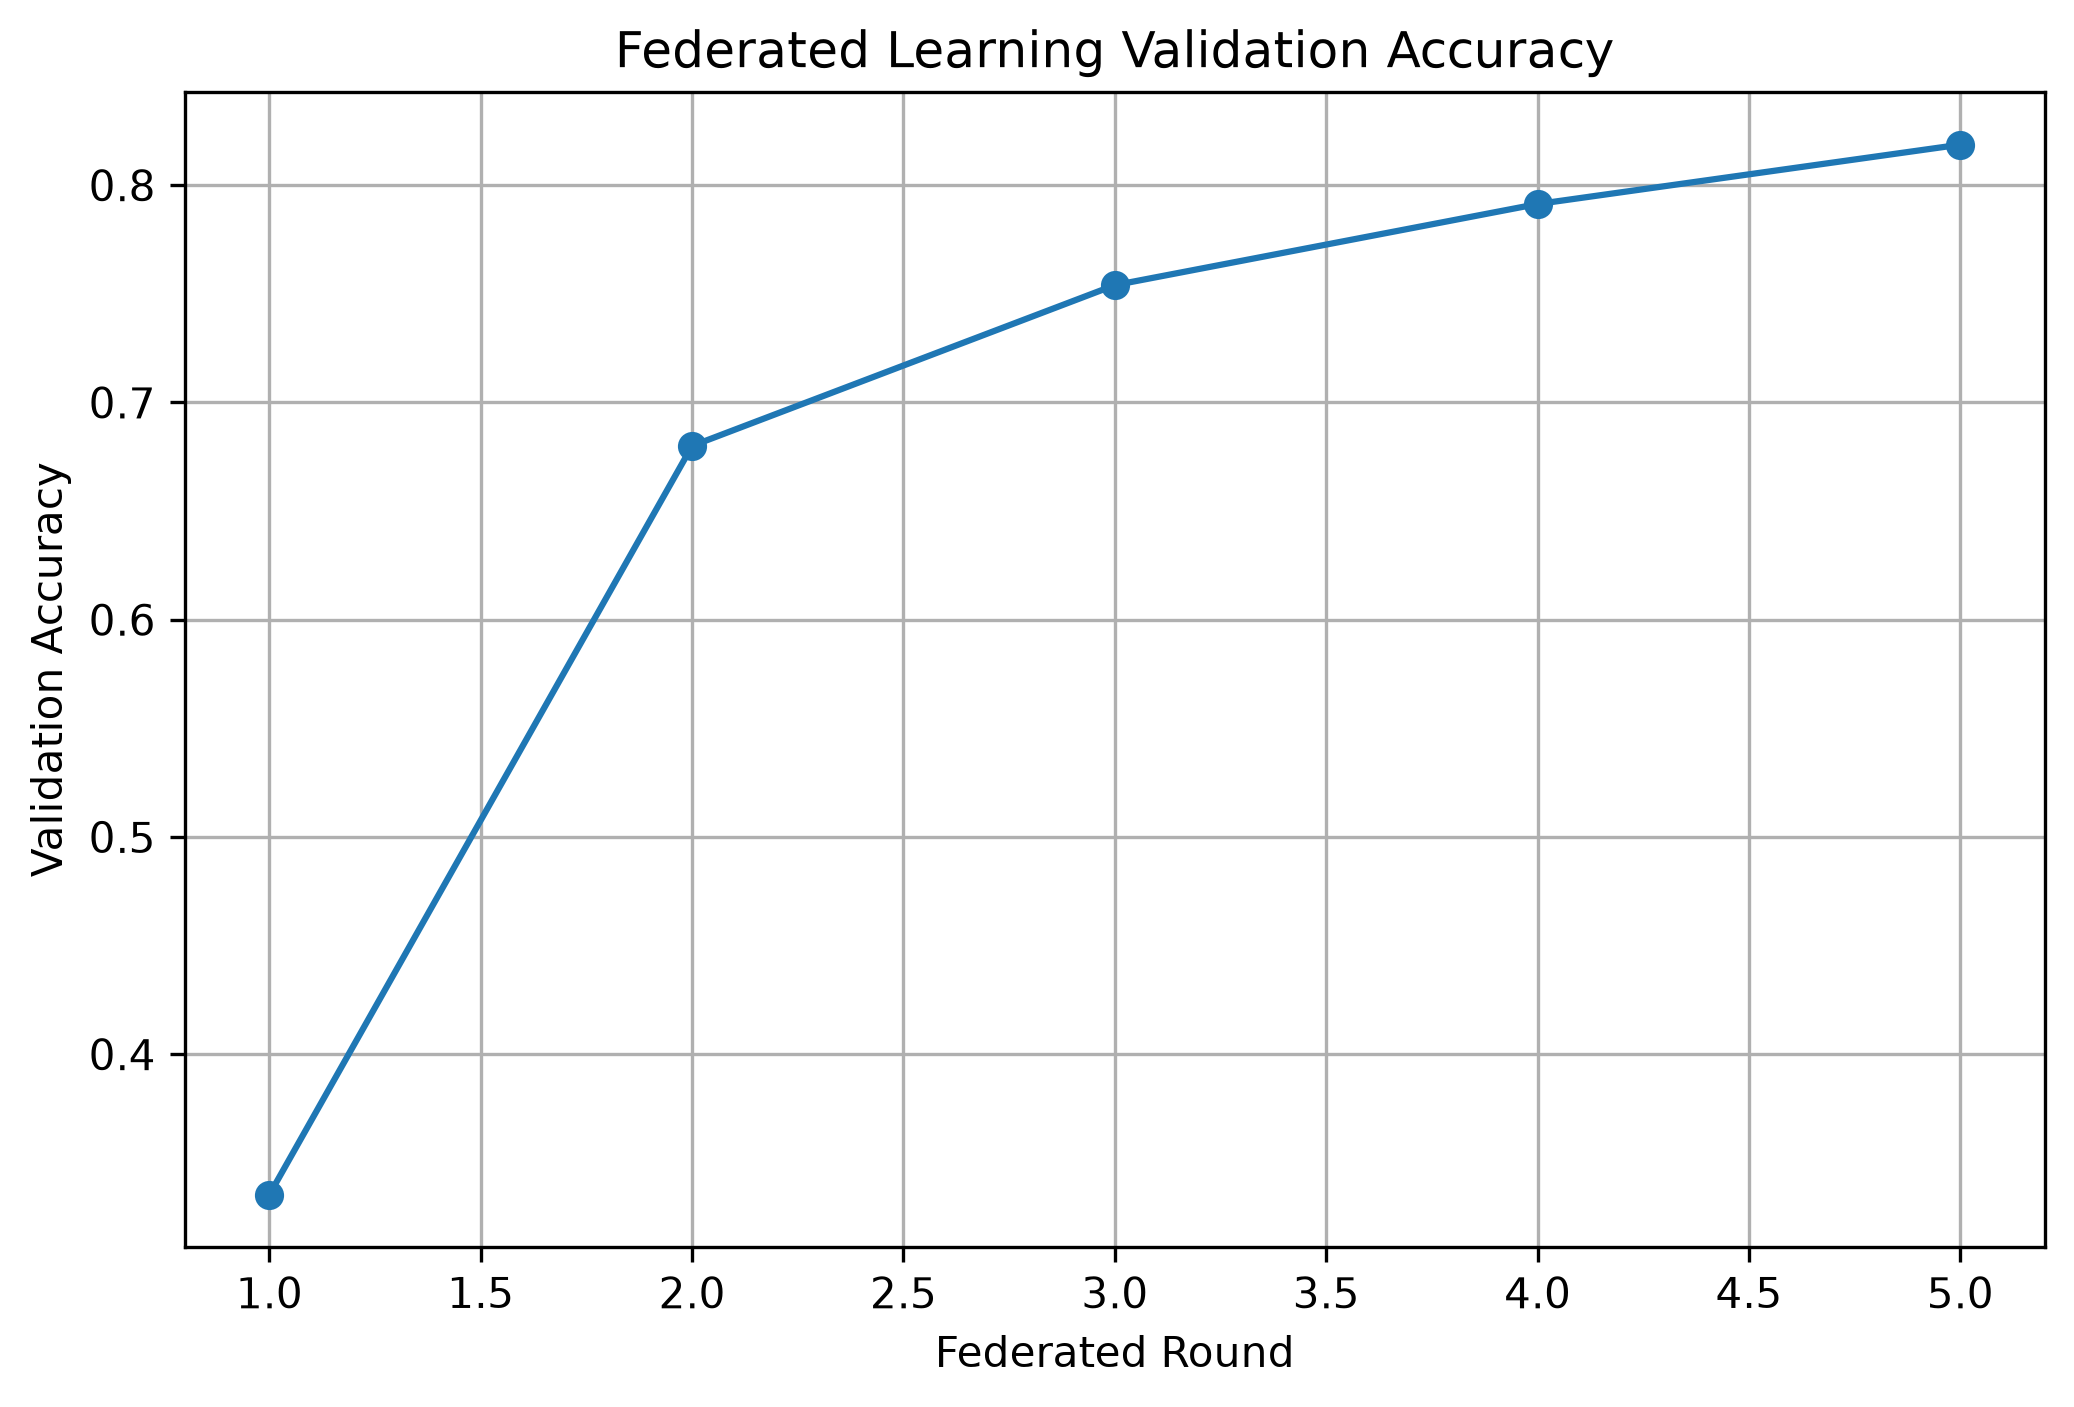


Phase 2 Federated Loss Graph


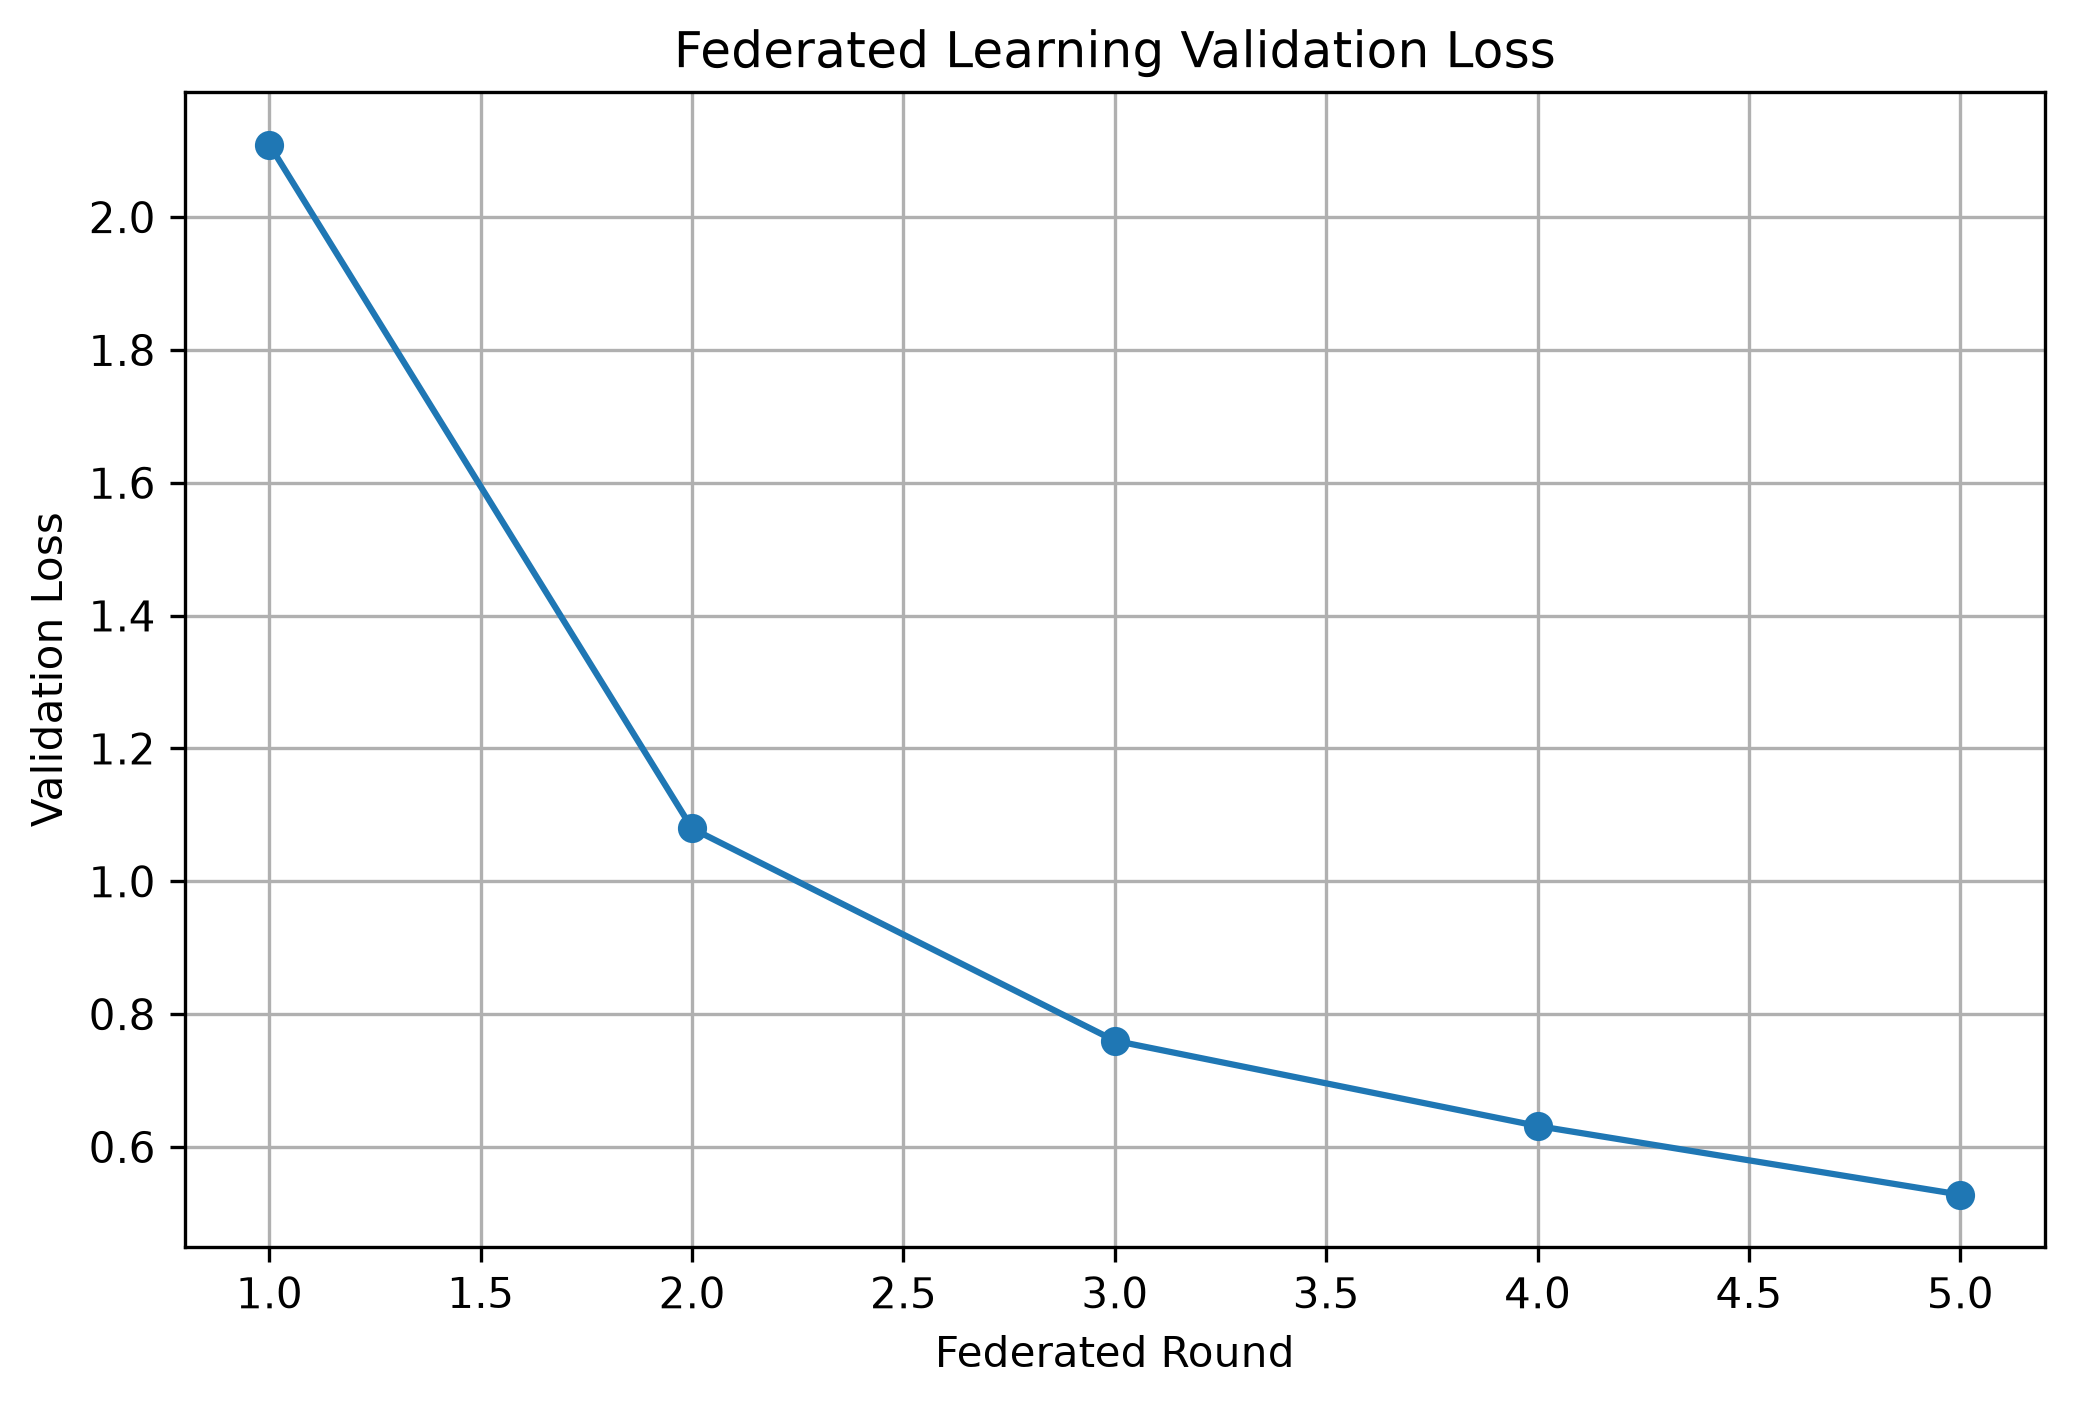


Phase 2 Federated Confusion Matrix


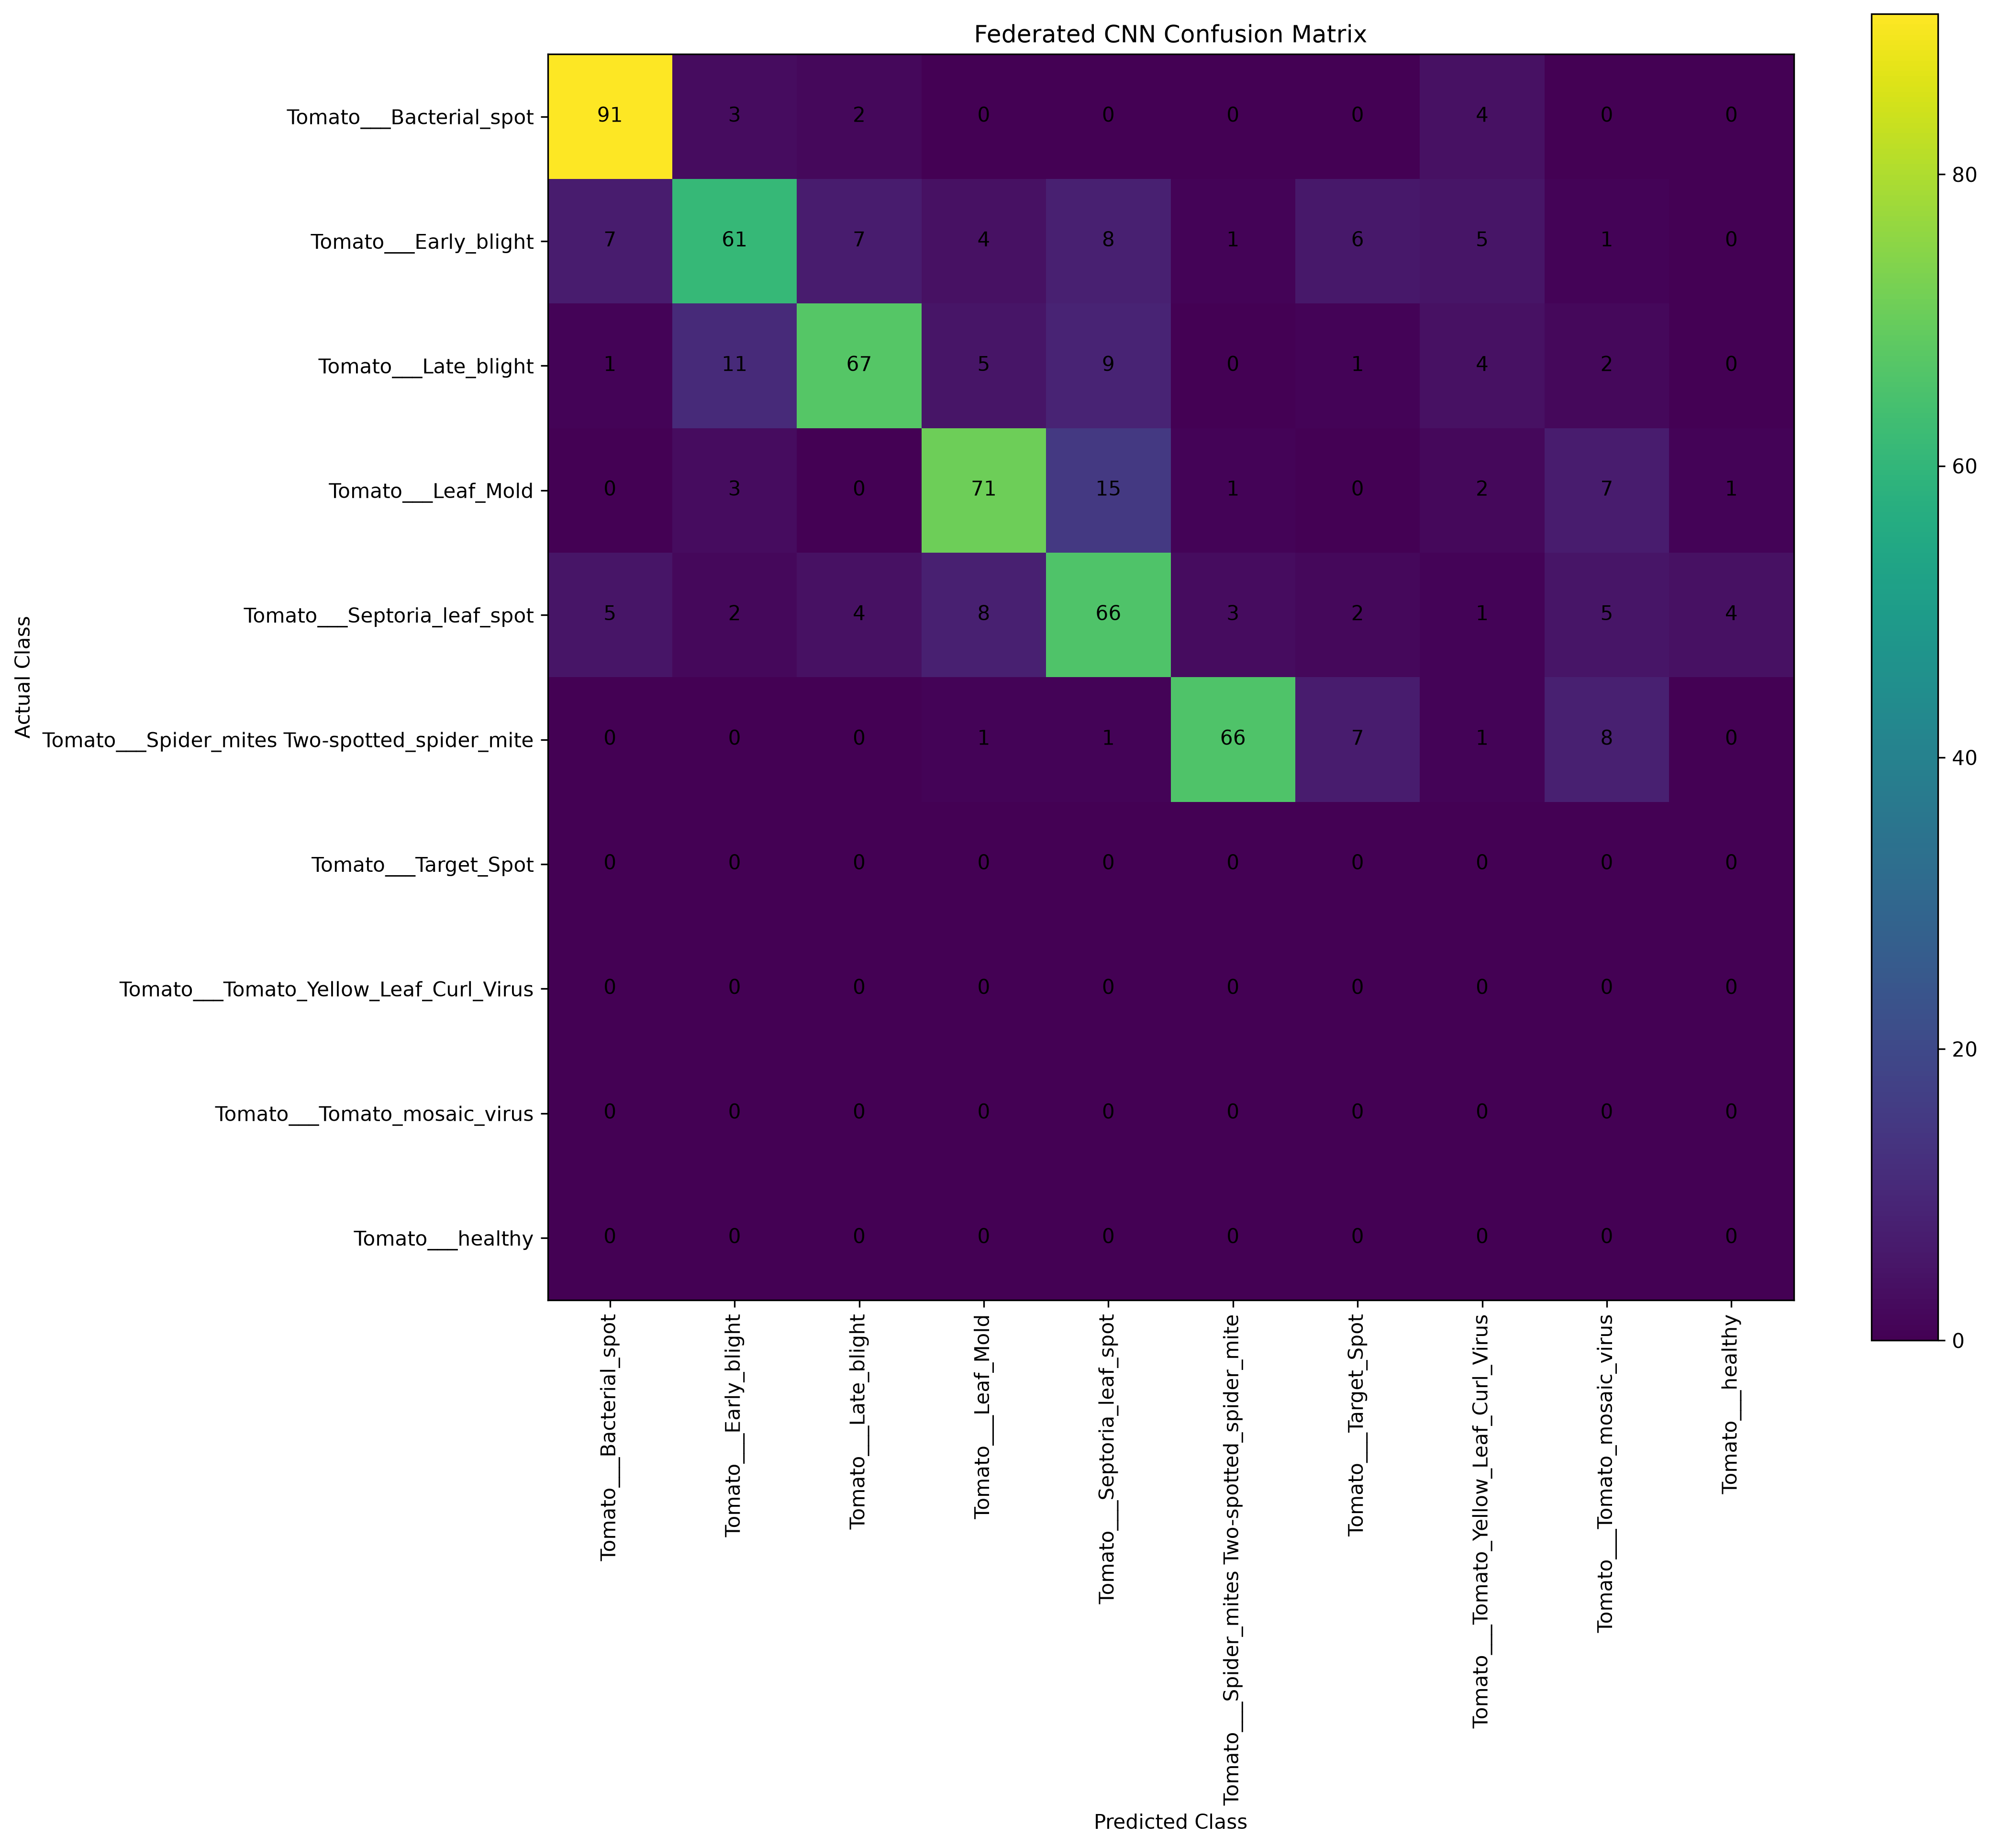


Phase 3 Model Comparison RMSE


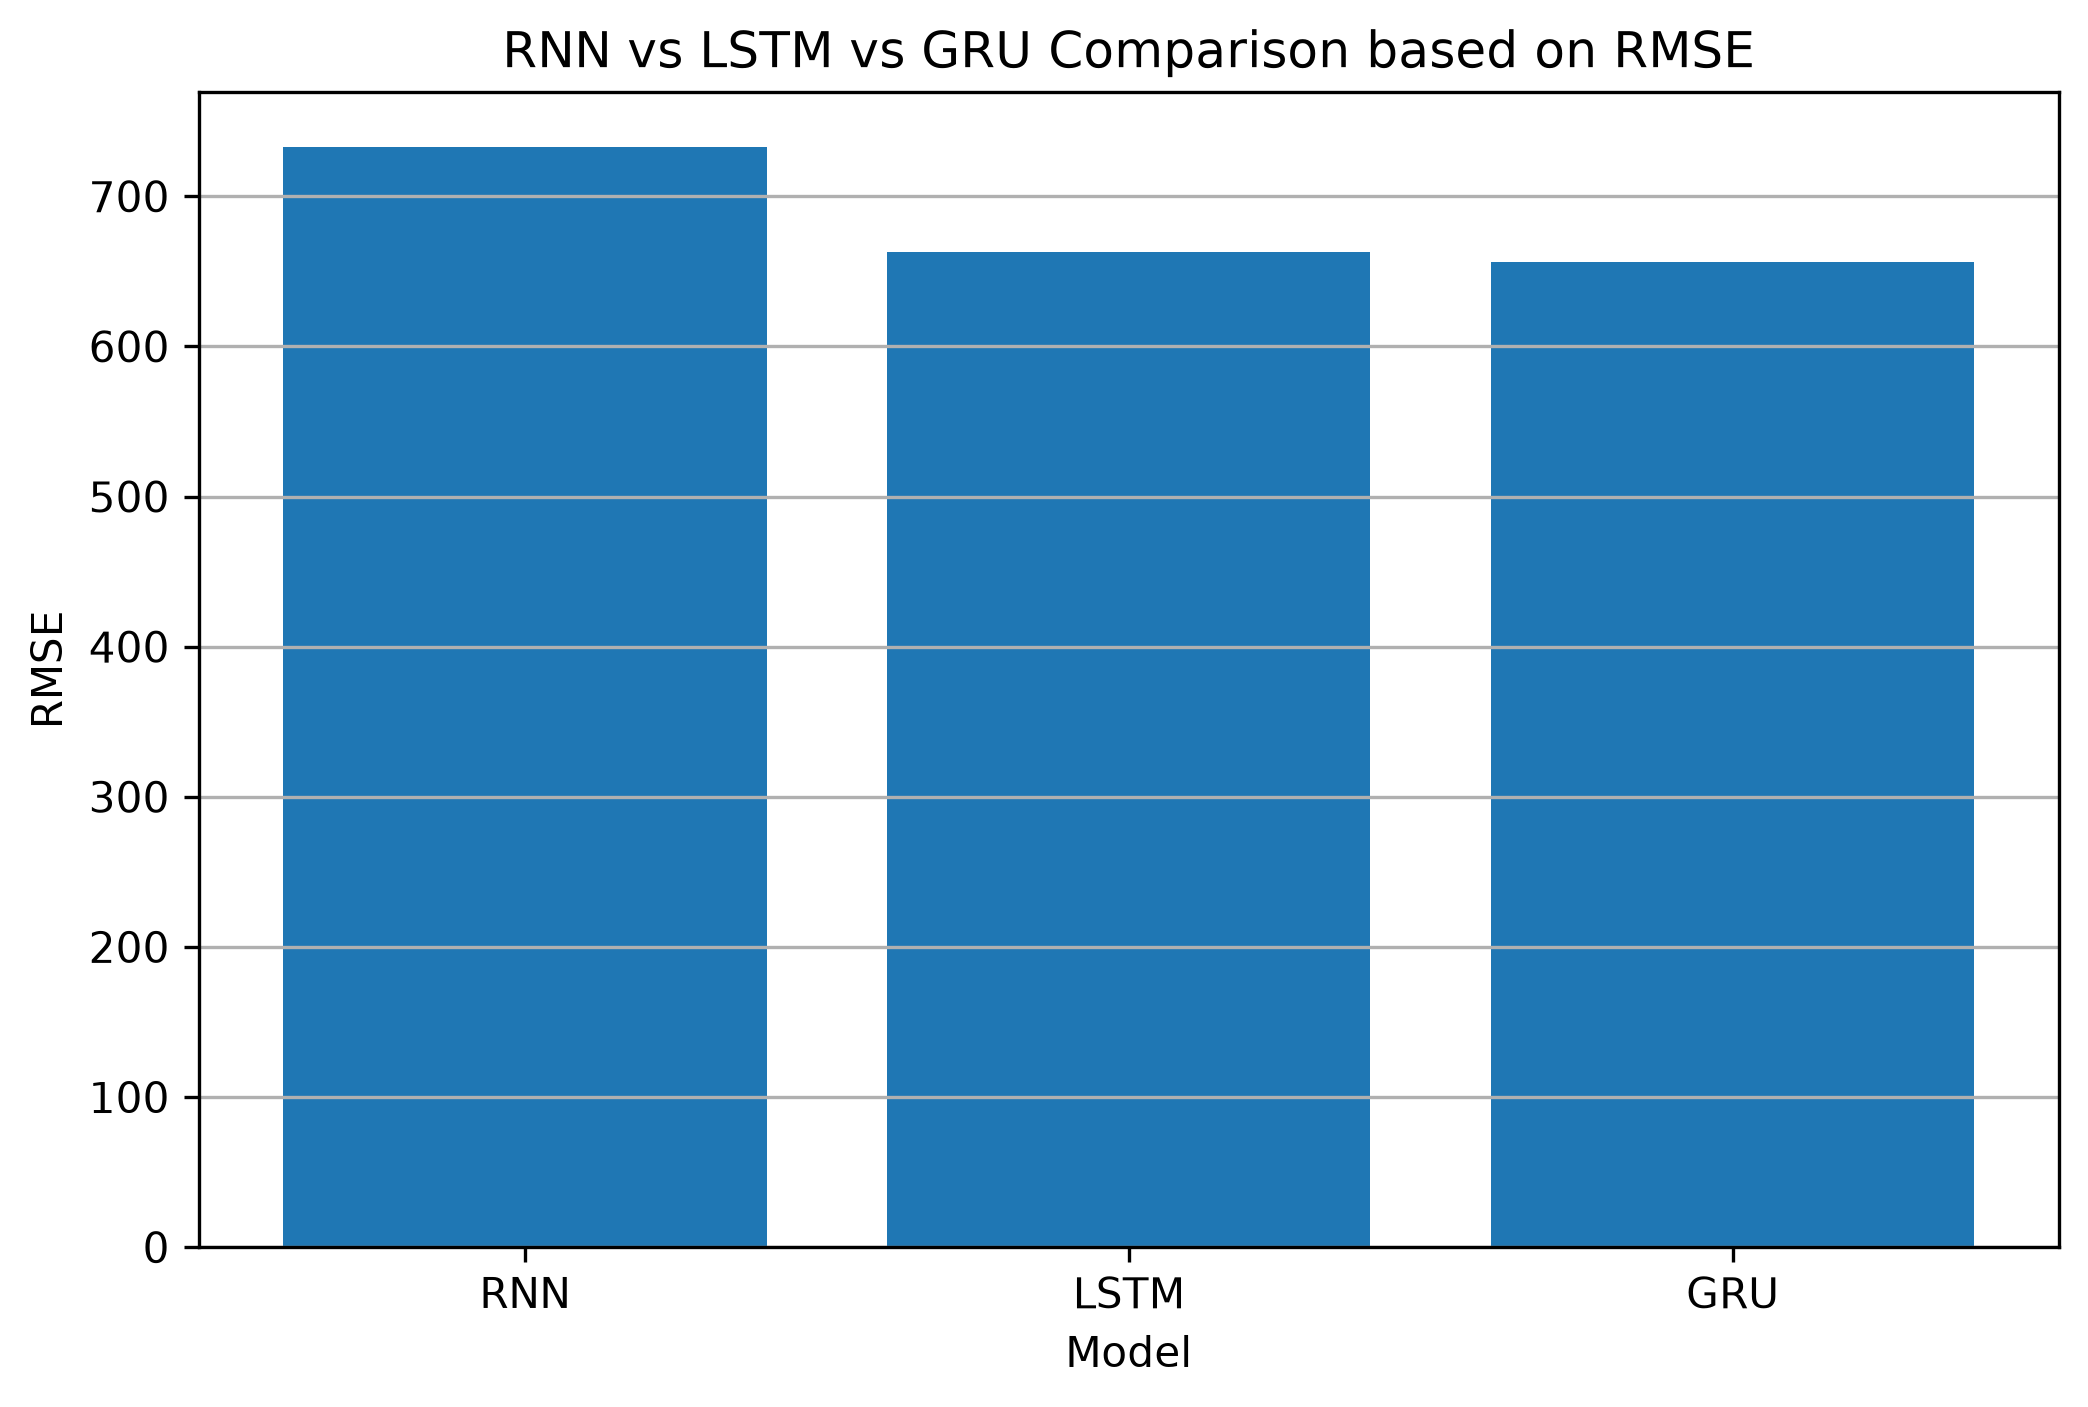


Phase 4 ANN Accuracy Graph


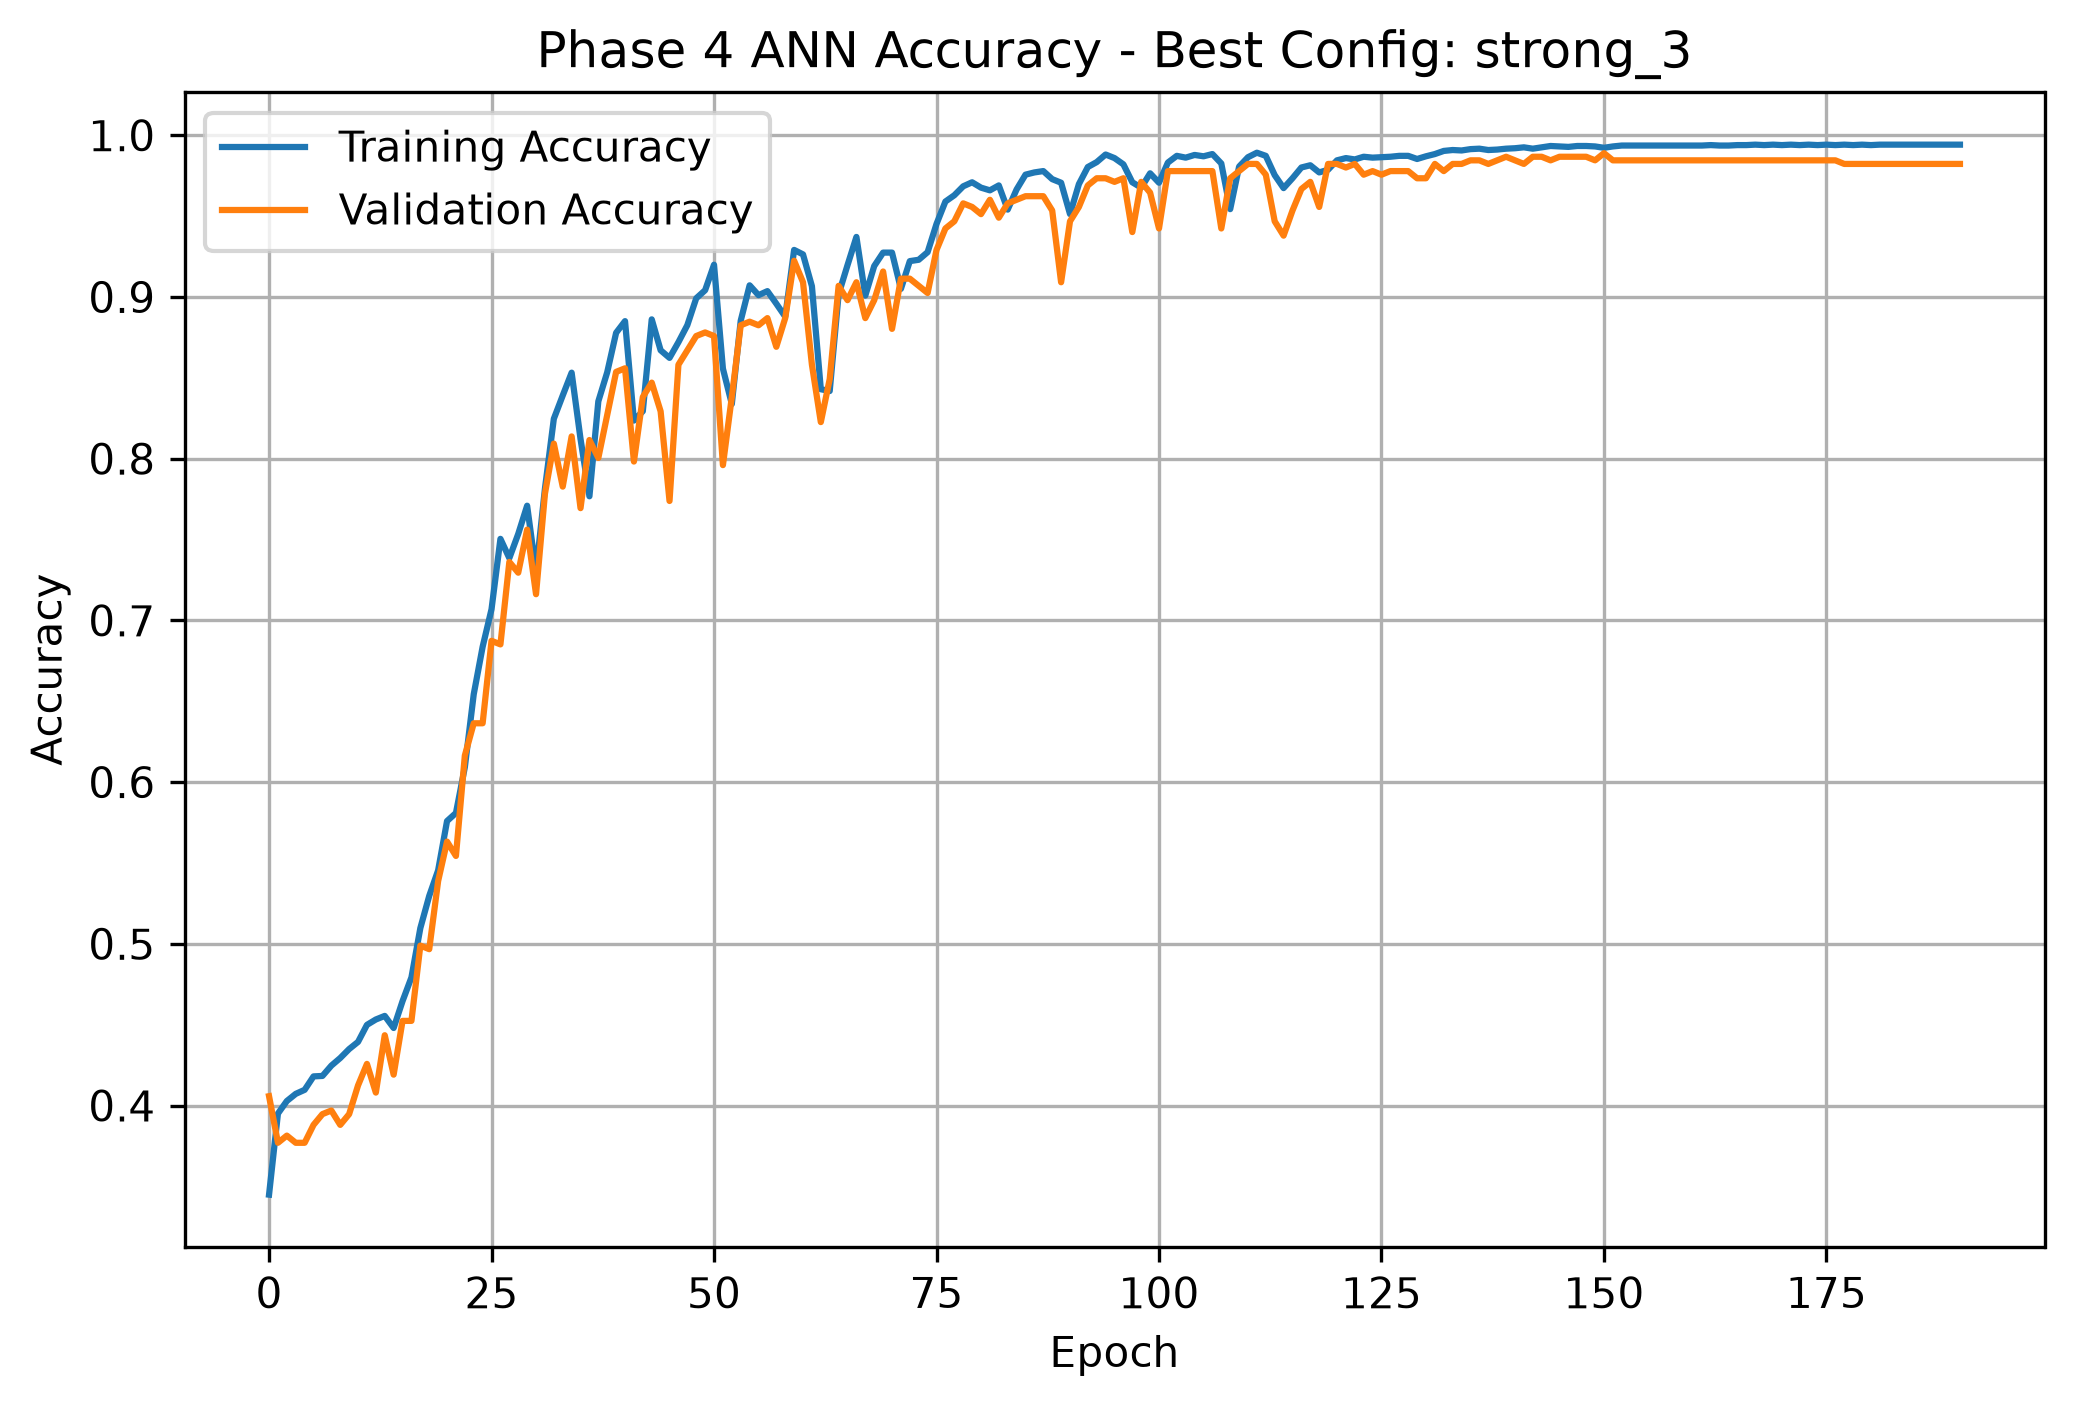


Phase 4 ANN Confusion Matrix


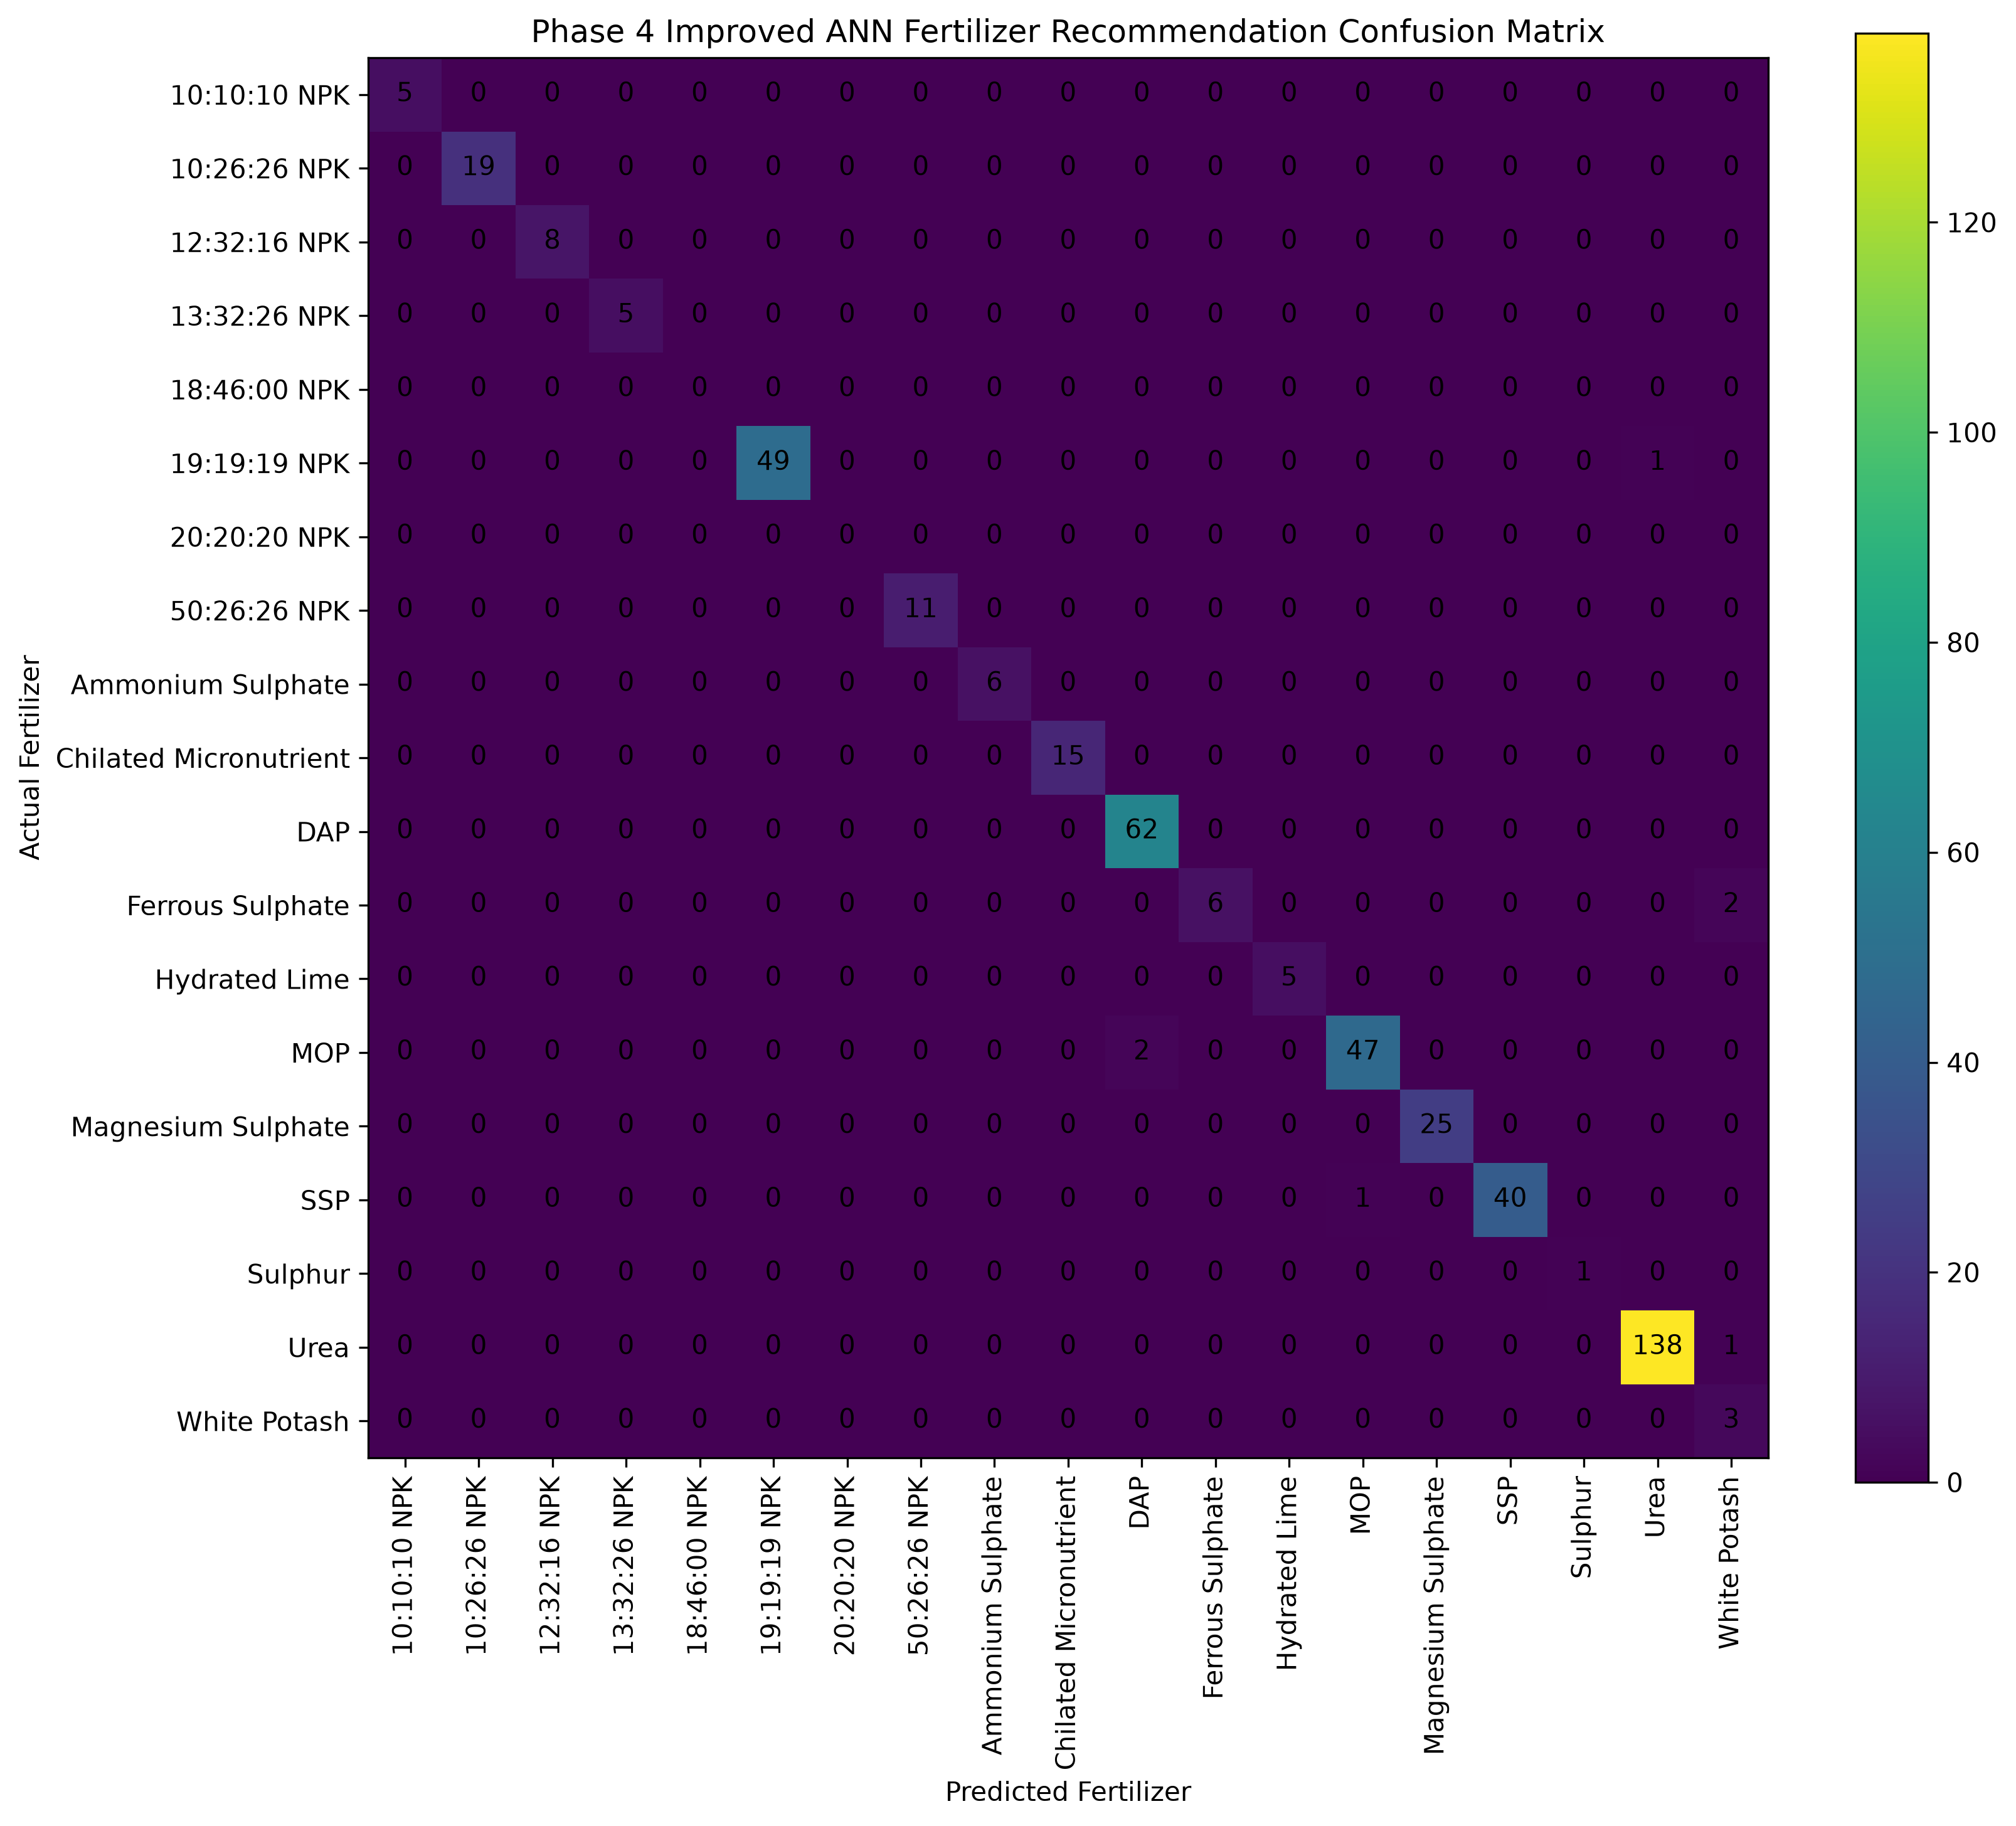


Phase 5 RL Moving Average Reward


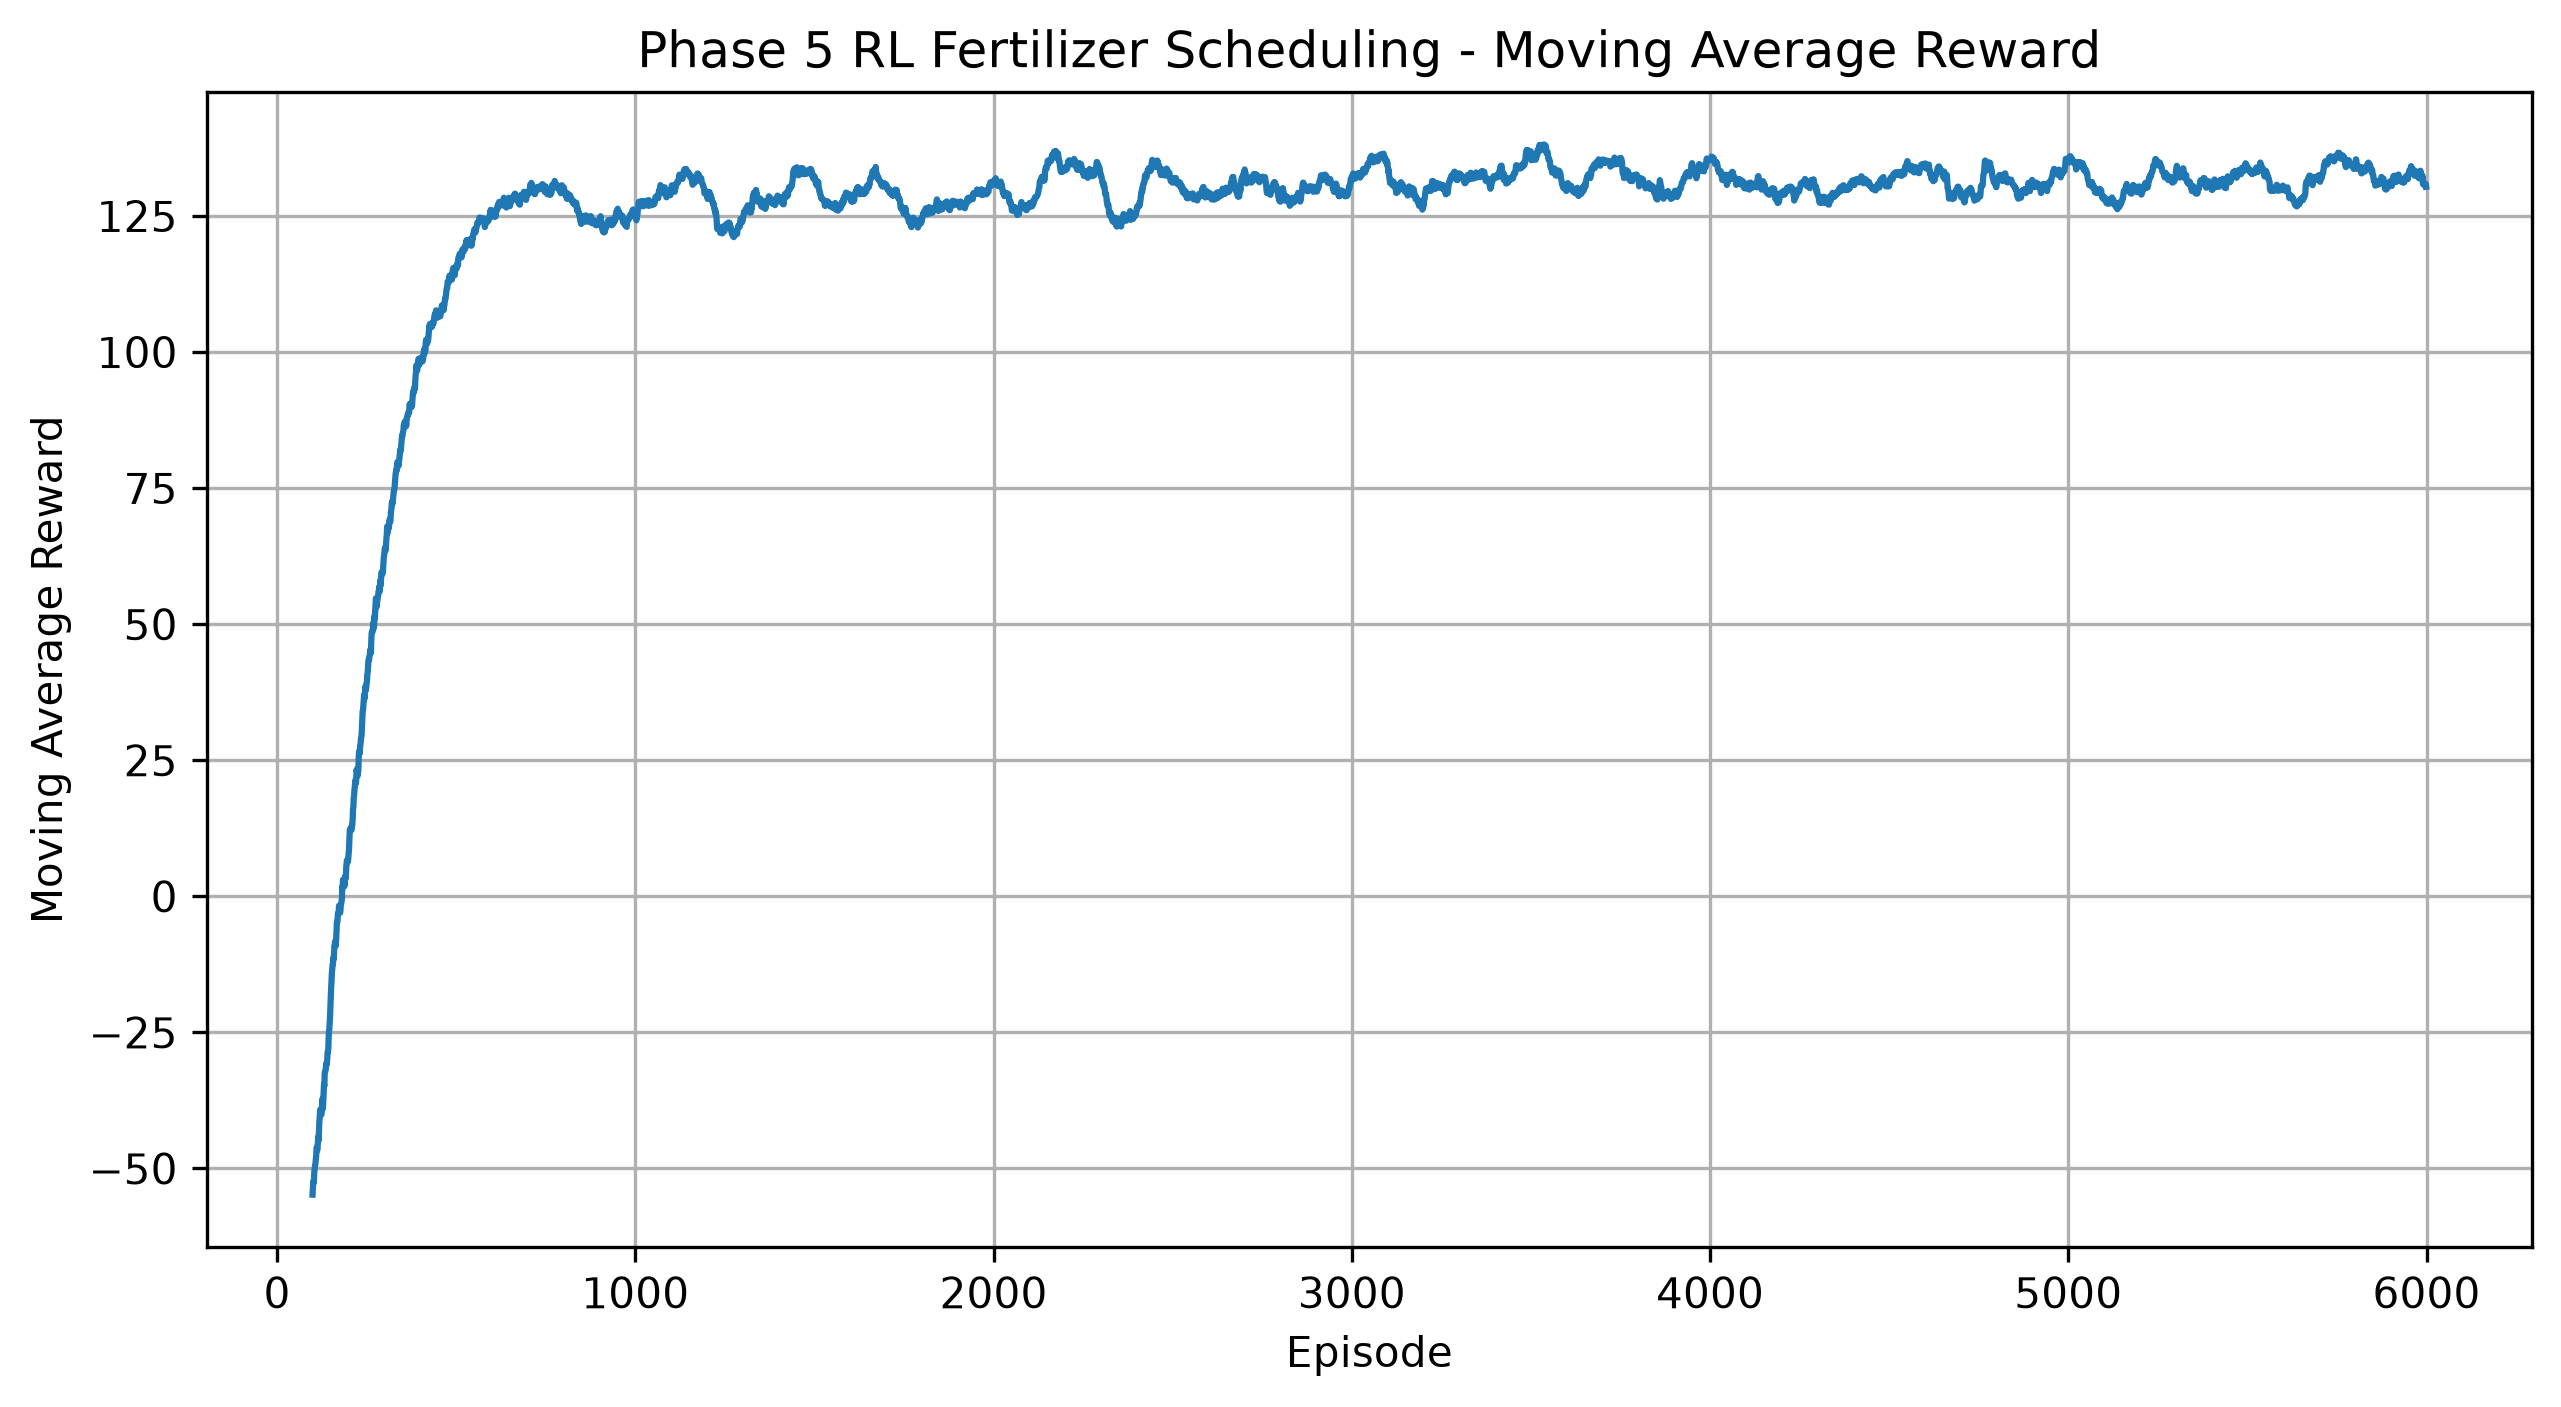


Phase 5 RL Policy Reward Comparison


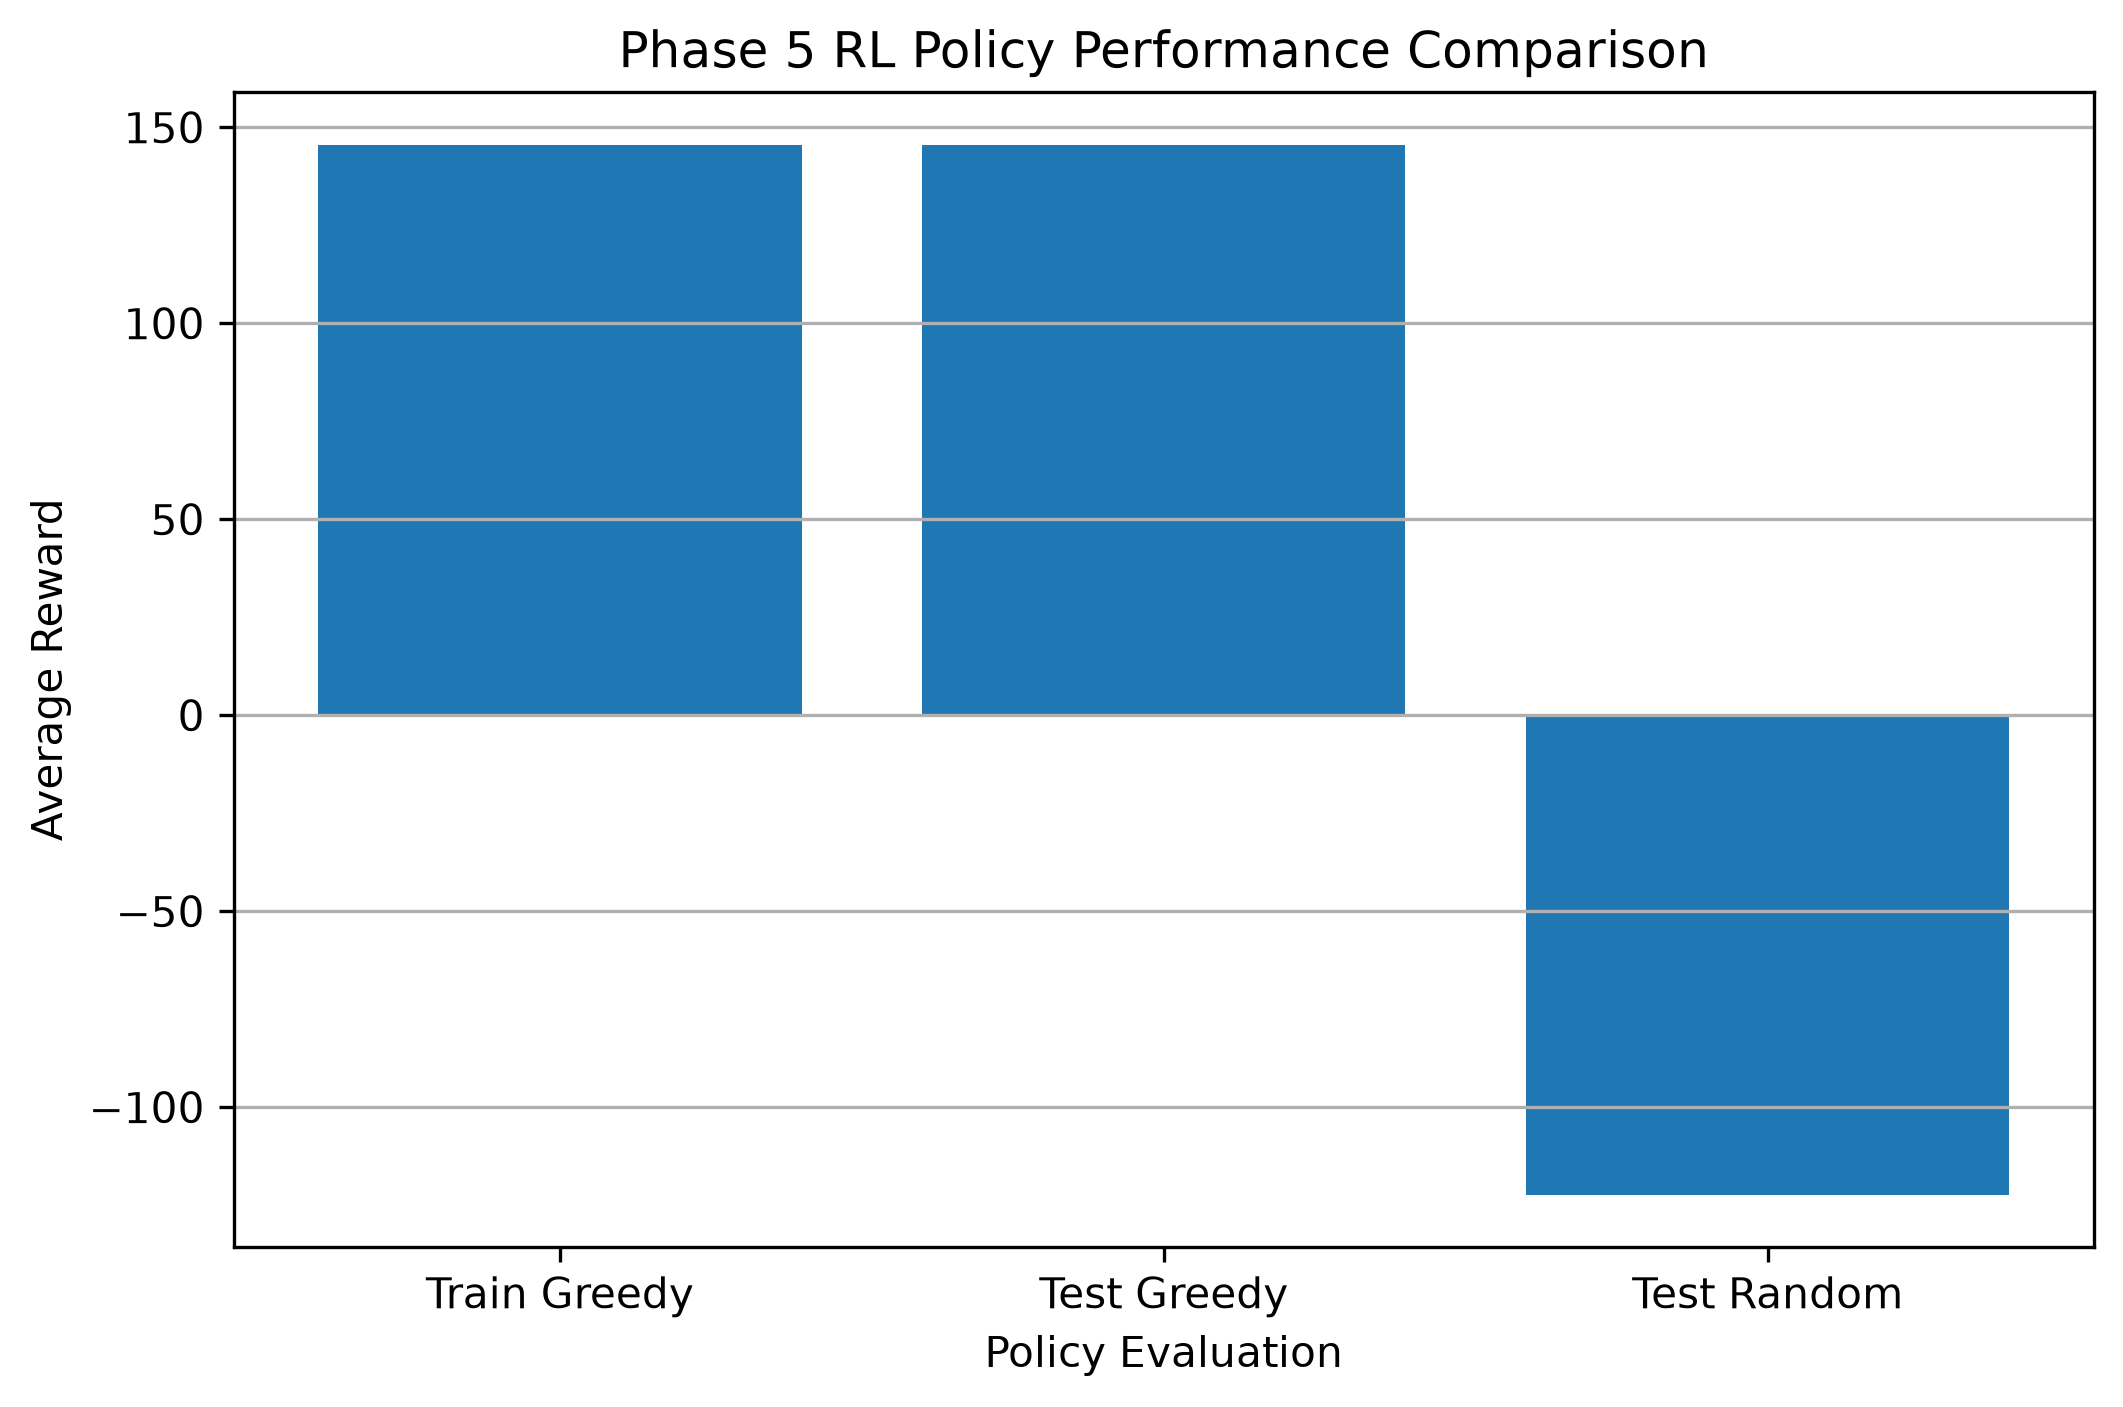


Phase 6 Expert System Confusion Matrix


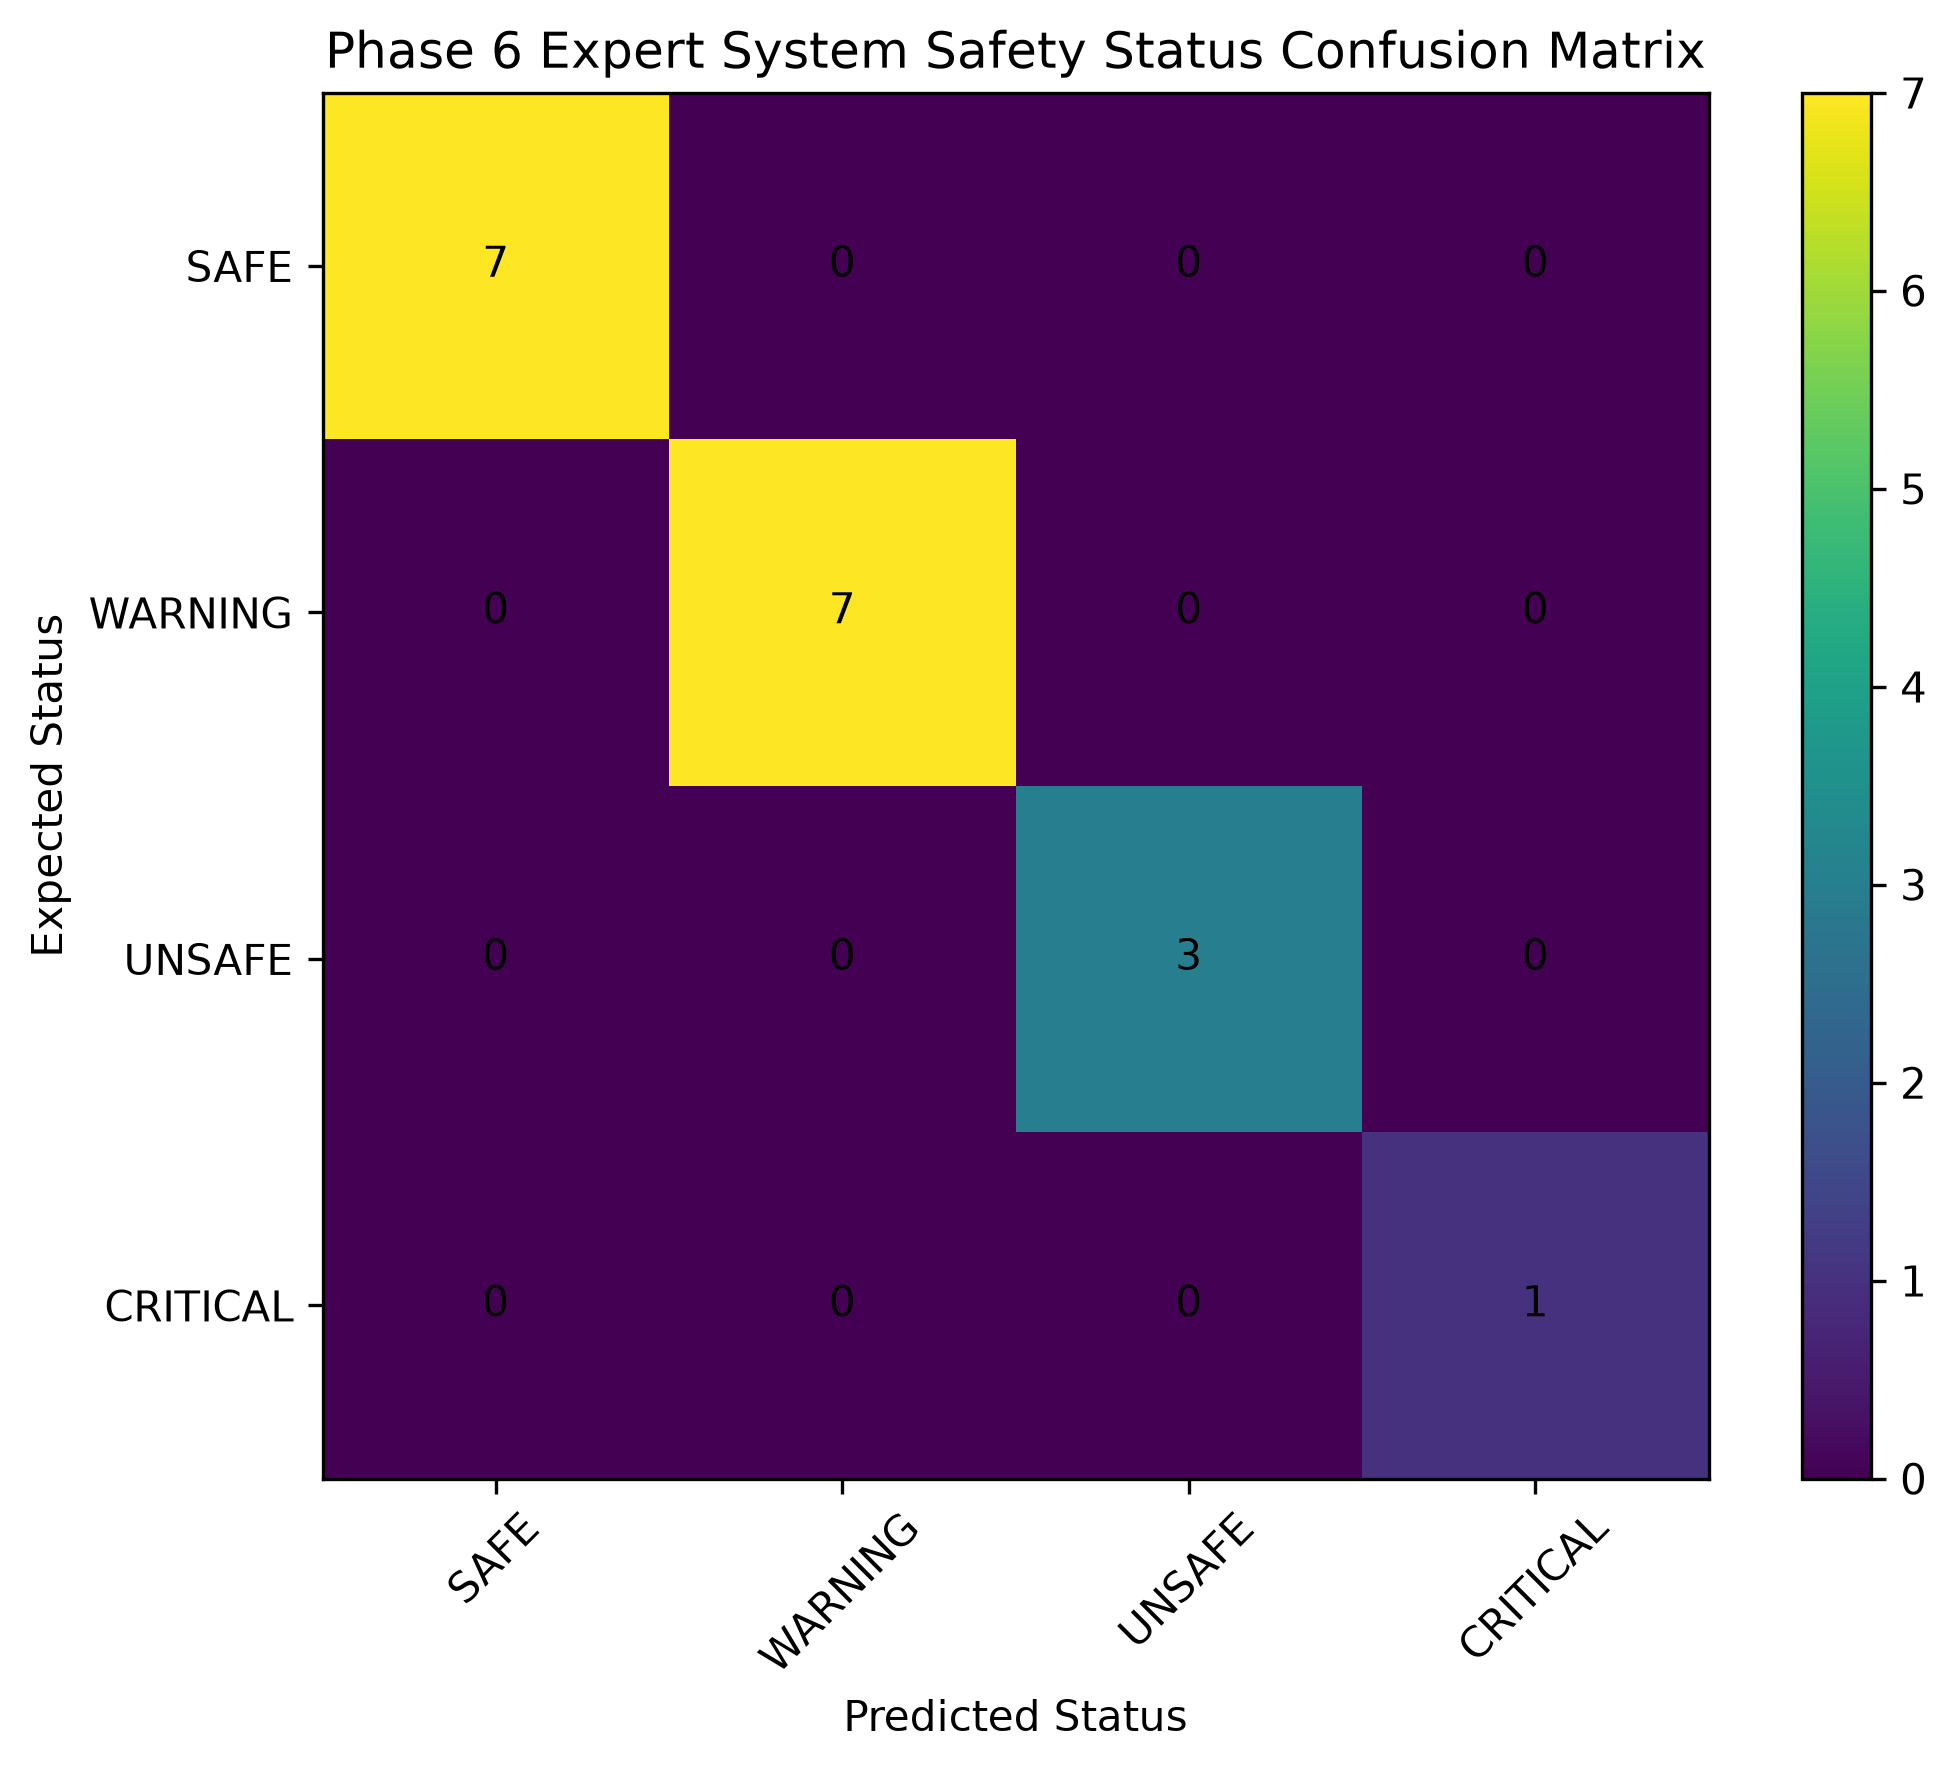

Important graph paths saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_important_graph_paths.csv


In [14]:
# ============================================================
# Block 14: Display important saved graphs from phases if available
# ============================================================

important_graphs = [
    {
        "Title": "Phase 1 CNN Accuracy Graph",
        "Path": os.path.join(phase_paths["phase1_cnn"]["screenshots_dir"], "accuracy_graph.png")
    },
    {
        "Title": "Phase 1 CNN Loss Graph",
        "Path": os.path.join(phase_paths["phase1_cnn"]["screenshots_dir"], "loss_graph.png")
    },
    {
        "Title": "Phase 1 CNN Confusion Matrix",
        "Path": os.path.join(phase_paths["phase1_cnn"]["screenshots_dir"], "confusion_matrix.png")
    },
    {
        "Title": "Phase 2 Federated Accuracy Graph",
        "Path": os.path.join(phase_paths["phase2_federated_cnn"]["screenshots_dir"], "phase2_federated_accuracy_graph.png")
    },
    {
        "Title": "Phase 2 Federated Loss Graph",
        "Path": os.path.join(phase_paths["phase2_federated_cnn"]["screenshots_dir"], "phase2_federated_loss_graph.png")
    },
    {
        "Title": "Phase 2 Federated Confusion Matrix",
        "Path": os.path.join(phase_paths["phase2_federated_cnn"]["screenshots_dir"], "phase2_federated_confusion_matrix.png")
    },
    {
        "Title": "Phase 3 Model Comparison RMSE",
        "Path": os.path.join(phase_paths["phase3_crop_price_forecasting"]["screenshots_dir"], "phase3_model_comparison_rmse.png")
    },
    {
        "Title": "Phase 4 ANN Accuracy Graph",
        "Path": os.path.join(phase_paths["phase4_ann_fertilizer"]["screenshots_dir"], "phase4_improved_ann_accuracy_graph.png")
    },
    {
        "Title": "Phase 4 ANN Confusion Matrix",
        "Path": os.path.join(phase_paths["phase4_ann_fertilizer"]["screenshots_dir"], "phase4_improved_ann_confusion_matrix.png")
    },
    {
        "Title": "Phase 5 RL Moving Average Reward",
        "Path": os.path.join(phase_paths["phase5_rl_scheduling"]["screenshots_dir"], "phase5_rl_moving_average_reward.png")
    },
    {
        "Title": "Phase 5 RL Policy Reward Comparison",
        "Path": os.path.join(phase_paths["phase5_rl_scheduling"]["screenshots_dir"], "phase5_rl_policy_reward_comparison.png")
    },
    {
        "Title": "Phase 6 Expert System Confusion Matrix",
        "Path": os.path.join(phase_paths["phase6_expert_system"]["screenshots_dir"], "phase6_confusion_matrix.png")
    }
]

important_graphs_df = pd.DataFrame(important_graphs)
display(important_graphs_df)

for graph in important_graphs:
    print("\n" + "="*80)
    show_image_if_exists(graph["Path"], graph["Title"])

important_graphs_path = os.path.join(FINAL_RESULTS_DIR, "final_important_graph_paths.csv")
important_graphs_df.to_csv(important_graphs_path, index=False)

print("Important graph paths saved at:", important_graphs_path)

In [15]:
# ============================================================
# Block 15: Create integrated AgriMind demo flow
# ============================================================

integrated_demo_flow = [
    {
        "Step": 1,
        "Module": "CNN Disease Detection",
        "Input": "Farmer captures/uploads crop leaf image",
        "Processing": "CNN detects plant disease condition",
        "Output": "Disease class and confidence"
    },
    {
        "Step": 2,
        "Module": "Federated Learning",
        "Input": "Local farmer device data",
        "Processing": "Model learns locally without uploading private images",
        "Output": "Privacy-preserving disease detection model update"
    },
    {
        "Step": 3,
        "Module": "Price Forecasting",
        "Input": "Historical crop/agricultural price sequence",
        "Processing": "RNN, LSTM, and GRU compare future price prediction",
        "Output": "Best forecasting model: GRU"
    },
    {
        "Step": 4,
        "Module": "ANN Fertilizer Recommendation",
        "Input": "Soil, crop, NPK, pH, rainfall, temperature data",
        "Processing": "ANN predicts suitable fertilizer",
        "Output": "Recommended fertilizer"
    },
    {
        "Step": 5,
        "Module": "RL Fertilizer Scheduling",
        "Input": "Nutrient need, price level, crop health, growth stage",
        "Processing": "Q-learning selects cost-aware scheduling action",
        "Output": "Apply low / normal / high amount or wait"
    },
    {
        "Step": 6,
        "Module": "Expert System Safety Checker",
        "Input": "Fertilizer/chemical recommendation",
        "Processing": "Rule base checks unsafe combinations and conditions",
        "Output": "SAFE / WARNING / UNSAFE / CRITICAL with reason"
    },
    {
        "Step": 7,
        "Module": "Final Advisory",
        "Input": "Outputs of all AI modules",
        "Processing": "Combine disease, price, fertilizer, schedule, and safety outputs",
        "Output": "Final safe and cost-aware advice to farmer"
    }
]

integrated_demo_flow_df = pd.DataFrame(integrated_demo_flow)
display(integrated_demo_flow_df)

demo_flow_path = os.path.join(FINAL_RESULTS_DIR, "final_integrated_demo_flow.csv")
integrated_demo_flow_df.to_csv(demo_flow_path, index=False)

print("Integrated demo flow saved at:", demo_flow_path)

,Step,Module,Input,Processing,Output
0,1,CNN Disease Detection,Farmer captures/uploads crop leaf image,CNN detects plant disease condition,Disease class and confidence
1,2,Federated Learning,Local farmer device data,Model learns locally without uploading private...,Privacy-preserving disease detection model update
2,3,Price Forecasting,Historical crop/agricultural price sequence,"RNN, LSTM, and GRU compare future price predic...",Best forecasting model: GRU
3,4,ANN Fertilizer Recommendation,"Soil, crop, NPK, pH, rainfall, temperature data",ANN predicts suitable fertilizer,Recommended fertilizer
4,5,RL Fertilizer Scheduling,"Nutrient need, price level, crop health, growt...",Q-learning selects cost-aware scheduling action,Apply low / normal / high amount or wait
5,6,Expert System Safety Checker,Fertilizer/chemical recommendation,Rule base checks unsafe combinations and condi...,SAFE / WARNING / UNSAFE / CRITICAL with reason
6,7,Final Advisory,Outputs of all AI modules,"Combine disease, price, fertilizer, schedule, ...",Final safe and cost-aware advice to farmer


Integrated demo flow saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_integrated_demo_flow.csv


In [16]:
# ============================================================
# Block 16: Create final example advisory output
# ============================================================

final_advisory_example = {
    "farmer_input": {
        "crop": "Tomato",
        "leaf_image_status": "Disease detection module executed",
        "soil_condition": {
            "nitrogen": "Medium",
            "phosphorus": "Medium",
            "potassium": "Medium",
            "soil_ph": 6.5
        },
        "growth_stage": "Middle"
    },
    "phase_outputs": {
        "phase1_cnn": {
            "output": "Plant disease detected / healthy status returned by CNN",
            "note": "Refer Phase 1 model output for exact class."
        },
        "phase2_federated_cnn": {
            "output": "Privacy-preserving federated CNN model completed",
            "note": "Farmer images are not directly uploaded to central server."
        },
        "phase3_forecasting": {
            "best_model": "GRU",
            "forecasting_target": "avg_modal_price",
            "selected_commodity": "Coconut",
            "note": "Used as related agricultural market price forecasting component."
        },
        "phase4_ann": {
            "output": "ANN recommends suitable fertilizer",
            "performance": "98.45% accuracy"
        },
        "phase5_rl": {
            "output": "Apply normal fertilizer amount",
            "reason": "RL policy balances nutrient need, crop health, growth stage, and cost."
        },
        "phase6_expert_system": {
            "safety_status": "SAFE",
            "reason": "No unsafe rule triggered.",
            "recommendation": "Apply according to recommended dosage and local agricultural guidance."
        }
    },
    "final_farmer_advice": (
        "Use the recommended fertilizer at the normal amount, follow the RL schedule, "
        "and apply only after the Expert System confirms that the recommendation is safe."
    )
}

print(json.dumps(final_advisory_example, indent=4))

final_advisory_path = os.path.join(FINAL_RESULTS_DIR, "final_integrated_advisory_example.json")

with open(final_advisory_path, "w") as f:
    json.dump(final_advisory_example, f, indent=4)

print("Final advisory example saved at:", final_advisory_path)

{
    "farmer_input": {
        "crop": "Tomato",
        "leaf_image_status": "Disease detection module executed",
        "soil_condition": {
            "nitrogen": "Medium",
            "phosphorus": "Medium",
            "potassium": "Medium",
            "soil_ph": 6.5
        },
        "growth_stage": "Middle"
    },
    "phase_outputs": {
        "phase1_cnn": {
            "output": "Plant disease detected / healthy status returned by CNN",
            "note": "Refer Phase 1 model output for exact class."
        },
        "phase2_federated_cnn": {
            "output": "Privacy-preserving federated CNN model completed",
            "note": "Farmer images are not directly uploaded to central server."
        },
        "phase3_forecasting": {
            "best_model": "GRU",
            "forecasting_target": "avg_modal_price",
            "selected_commodity": "Coconut",
            "note": "Used as related agricultural market price forecasting component."
        },
       

In [17]:
# ============================================================
# Block 17: Final limitations and honest notes
# ============================================================

limitations = pd.DataFrame([
    {
        "Area": "Phase 3 Dataset",
        "Limitation": "Direct pesticide/fertilizer price datasets were limited.",
        "Honest_Report_Note": "Crop price forecasting was used as a related agricultural market price forecasting component."
    },
    {
        "Area": "Phase 5 RL Environment",
        "Limitation": "Real farm trial-and-error fertilizer scheduling data was not available.",
        "Honest_Report_Note": "A simulated RL farming environment was created using realistic agricultural states."
    },
    {
        "Area": "Phase 6 Expert System",
        "Limitation": "Rule base is manually created for prototype level.",
        "Honest_Report_Note": "Production systems should validate and expand rules using official agricultural handbooks and domain experts."
    },
    {
        "Area": "System Integration",
        "Limitation": "Final notebook summarizes modules rather than deploying a full mobile/web application.",
        "Honest_Report_Note": "Future work can integrate all models into a complete mobile advisory app."
    }
])

display(limitations)

limitations_path = os.path.join(FINAL_RESULTS_DIR, "final_limitations_and_honest_notes.csv")
limitations.to_csv(limitations_path, index=False)

print("Limitations and honest notes saved at:", limitations_path)

,Area,Limitation,Honest_Report_Note
0,Phase 3 Dataset,Direct pesticide/fertilizer price datasets wer...,Crop price forecasting was used as a related a...
1,Phase 5 RL Environment,Real farm trial-and-error fertilizer schedulin...,A simulated RL farming environment was created...
2,Phase 6 Expert System,Rule base is manually created for prototype le...,Production systems should validate and expand ...
3,System Integration,Final notebook summarizes modules rather than ...,Future work can integrate all models into a co...


Limitations and honest notes saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_limitations_and_honest_notes.csv


In [18]:
# ============================================================
# Block 18: Future improvements
# ============================================================

future_improvements = pd.DataFrame([
    {
        "Improvement": "Use real fertilizer and pesticide price datasets",
        "Reason": "To improve Objective 2 alignment with pesticide/supply price forecasting."
    },
    {
        "Improvement": "Collect real field trial data for RL",
        "Reason": "To replace the simulated environment with real farm decision outcomes."
    },
    {
        "Improvement": "Expand Expert System rule base",
        "Reason": "To cover more chemical combinations, crop-specific restrictions, and official safety guidelines."
    },
    {
        "Improvement": "Develop mobile application",
        "Reason": "To deliver disease detection and advisory outputs directly to farmers."
    },
    {
        "Improvement": "Connect all modules through an API",
        "Reason": "To make the AgriMind system usable as one integrated software platform."
    }
])

display(future_improvements)

future_improvements_path = os.path.join(FINAL_RESULTS_DIR, "final_future_improvements.csv")
future_improvements.to_csv(future_improvements_path, index=False)

print("Future improvements saved at:", future_improvements_path)

,Improvement,Reason
0,Use real fertilizer and pesticide price datasets,To improve Objective 2 alignment with pesticid...
1,Collect real field trial data for RL,To replace the simulated environment with real...
2,Expand Expert System rule base,"To cover more chemical combinations, crop-spec..."
3,Develop mobile application,To deliver disease detection and advisory outp...
4,Connect all modules through an API,To make the AgriMind system usable as one inte...


Future improvements saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_future_improvements.csv


In [19]:
# ============================================================
# Block 19: Final completion report JSON
# ============================================================

final_completion_report = {
    "project_title": "AgriMind: A Federated Multi-Model AI Advisory System for Crop Health and Supply Chain Optimization",
    "final_status": "Completed",
    "completed_objectives": objective_mapping.to_dict(orient="records"),
    "phase_results": final_results.to_dict(orient="records"),
    "important_notes": {
        "phase1": "Centralized CNN plant disease detection completed and included in final demo summary.",
        "phase2": "Federated CNN plant disease detection completed and included in final demo summary.",
        "phase3": "Crop price forecasting was used as a related agricultural market price forecasting component due to limited direct pesticide/fertilizer price datasets.",
        "phase5": "RL fertilizer scheduling used a simulated farming environment.",
        "phase6": "Expert System is symbolic AI / rule-based AI and does not require ML training."
    },
    "final_outputs": {
        "objective_mapping": objective_mapping_path,
        "phase_results_summary": final_results_path,
        "phase1_phase2_demo_files": phase1_phase2_demo_files_path,
        "demo_flow": demo_flow_path,
        "final_advisory_example": final_advisory_path,
        "limitations": limitations_path,
        "future_improvements": future_improvements_path,
        "objective_completion_graph": objective_completion_path,
        "ai_technology_graph": ai_technology_path
    },
    "coding_status": "After running this notebook successfully, the coding/model-development part is complete."
}

final_completion_report_path = os.path.join(FINAL_RESULTS_DIR, "final_project_completion_report.json")

with open(final_completion_report_path, "w") as f:
    json.dump(final_completion_report, f, indent=4)

print("Final completion report saved at:", final_completion_report_path)

Final completion report saved at: E:\AI Project\AgriMind_Project\results\phase7_final_integration\final_project_completion_report.json


In [20]:
# ============================================================
# Block 20: Final project summary
# ============================================================

print("============================================================")
print("AgriMind Final Integration Completed")
print("============================================================")
print("Project:", final_completion_report["project_title"])
print("Final status:", final_completion_report["final_status"])
print()
print("Completed objectives:")
for _, row in objective_mapping.iterrows():
    print("-", row["Objective"], ":", row["Completed Phase"], "|", row["Status"])

print()
print("Main results:")
print("- Phase 1 CNN disease detection: Completed and included in final demo")
print("- Phase 2 Federated CNN disease detection: Completed and included in final demo")
print("- Phase 3 best model: GRU for crop price forecasting")
print("- Phase 4 ANN fertilizer recommendation accuracy: 98.45%")
print("- Phase 5 RL reward improvement: 185.1642")
print("- Phase 5 test improvement over random policy: 267.8365")
print("- Phase 6 Expert System accuracy: 100%")
print("- Phase 6 false-safe cases: 0")
print()
print("Final outputs saved in:")
print(FINAL_RESULTS_DIR)
print(FINAL_SCREENSHOTS_DIR)
print("============================================================")
print("Coding/model-development part is now complete.")
print("Next work: final report, presentation, demo explanation, and contribution section.")
print("============================================================")

AgriMind Final Integration Completed
Project: AgriMind: A Federated Multi-Model AI Advisory System for Crop Health and Supply Chain Optimization
Final status: Completed

Completed objectives:
- Objective 1 : Phase 1 + Phase 2 | Completed
- Objective 2 : Phase 3 | Completed
- Objective 3 : Phase 5 | Completed
- Objective 4 : Phase 6 | Completed
- Objective 5 : Phase 4 | Completed

Main results:
- Phase 1 CNN disease detection: Completed and included in final demo
- Phase 2 Federated CNN disease detection: Completed and included in final demo
- Phase 3 best model: GRU for crop price forecasting
- Phase 4 ANN fertilizer recommendation accuracy: 98.45%
- Phase 5 RL reward improvement: 185.1642
- Phase 5 test improvement over random policy: 267.8365
- Phase 6 Expert System accuracy: 100%
- Phase 6 false-safe cases: 0

Final outputs saved in:
E:\AI Project\AgriMind_Project\results\phase7_final_integration
E:\AI Project\AgriMind_Project\screenshots\phase7_final_integration
Coding/model-develo